# Evaluación Parcial 1 – Deep Learning
# Clasificación de Lengua de Señas con Redes Neuronales

## 1. Objetivo y descripción del problema

Desarrollar y evaluar una red neuronal artificial tipo **MLP (Multilayer Perceptron)** capaz de clasificar imágenes correspondientes a letras de la lengua de señas utilizando el dataset Sign Language MNIST.

Durante el desarrollo se realizarán experimentos controlados sobre funciones de activación, funciones de pérdida, hiperparámetros y arquitectura de la MLP, comparando su impacto mediante métricas y curvas de aprendizaje.

Finalmente, se seleccionará una configuración utilizando el conjunto de validación y se evaluará su capacidad de generalización sobre un conjunto de prueba independiente.

## 2. Carga del dataset

El dataset se descarga directamente desde Kaggle mediante la librería `kagglehub`.

Se utilizan dos archivos principales:

- `sign_mnist_train.csv`: conjunto de entrenamiento original.
- `sign_mnist_test.csv`: conjunto de prueba original.

Cada fila representa una imagen de **28×28 píxeles en escala de grises**, almacenada como 784 valores numéricos, además de una columna `label` que identifica la clase correspondiente.

In [304]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("datamunge/sign-language-mnist")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sign-language-mnist' dataset.
Path to dataset files: /kaggle/input/sign-language-mnist


In [305]:
import os

print("Contenido del dataset:")
for archivo in os.listdir(path):
    print("-", archivo)

Contenido del dataset:
- sign_mnist_test.csv
- sign_mnist_test
- sign_mnist_train
- amer_sign2.png
- amer_sign3.png
- sign_mnist_train.csv
- american_sign_language.PNG


### 2.1 Inspección inicial

Se revisa la estructura del dataset para conocer:

- cantidad de ejemplos disponibles,
- número de variables,
- formato de las etiquetas,
- distribución de las clases.

El conjunto de entrenamiento contiene **27.455 ejemplos** y el conjunto de prueba **7.172 ejemplos**. Cada registro contiene una etiqueta y 784 valores de píxeles.

In [306]:
import pandas as pd

train_path = os.path.join(path, "sign_mnist_train.csv")
test_path = os.path.join(path, "sign_mnist_test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train:", train_df.shape)
print("Test:", test_df.shape)

train_df.head()

Train: (27455, 785)
Test: (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


### 2.2 Distribución de clases

El dataset contiene **24 clases**. Las etiquetas no son completamente consecutivas, ya que no se incluyen las letras **J** y **Z**.

La cantidad de ejemplos por clase es relativamente similar, por lo que no se observa un desbalance severo que requiera técnicas especiales de balanceo en esta etapa.

In [307]:
print(train_df.info())

print("\nClases disponibles:")
print(sorted(train_df["label"].unique()))

print("\nCantidad de ejemplos por clase:")
print(train_df["label"].value_counts().sort_index())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27455 entries, 0 to 27454
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 164.4 MB
None

Clases disponibles:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]

Cantidad de ejemplos por clase:
label
0     1126
1     1010
2     1144
3     1196
4      957
5     1204
6     1090
7     1013
8     1162
10    1114
11    1241
12    1055
13    1151
14    1196
15    1088
16    1279
17    1294
18    1199
19    1186
20    1161
21    1082
22    1225
23    1164
24    1118
Name: count, dtype: int64


### 2.3 Visualización de ejemplos

Se reconstruyen los vectores de 784 píxeles como imágenes de **28×28 píxeles** para observar visualmente algunas muestras del dataset.

Esta exploración permite comprobar que las imágenes corresponden efectivamente a diferentes gestos del alfabeto de lengua de señas.

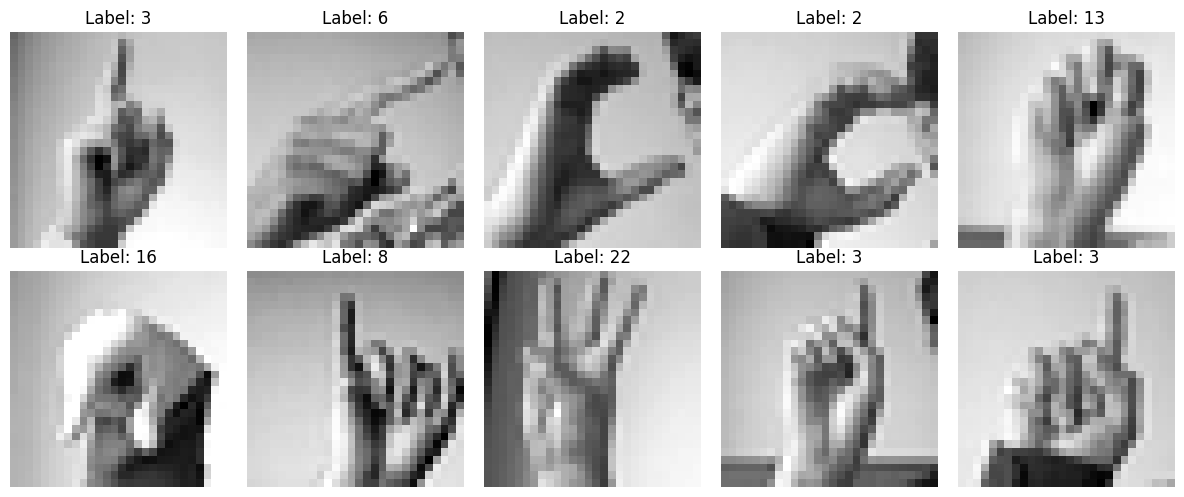

In [308]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    imagen = train_df.iloc[i, 1:].values.reshape(28, 28)
    label = train_df.iloc[i, 0]

    ax.imshow(imagen, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 3. Preprocesamiento de los datos

Antes del entrenamiento es necesario adaptar los datos al formato esperado por la red neuronal.

### 3.1 Remapeo de etiquetas

Las etiquetas originales no son consecutivas, ya que las clases correspondientes a las letras J y Z no están presentes.

Para evitar problemas en la capa de salida, las etiquetas originales se remapean a índices consecutivos entre 0 y 23.

De esta forma, la red puede utilizar una capa de salida de 24 neuronas, una por cada clase disponible.

In [309]:
# Etiquetas originales disponibles
labels_originales = sorted(train_df["label"].unique())

# Mapeo: etiqueta original -> índice consecutivo 0...23
label_to_index = {
    label: i
    for i, label in enumerate(labels_originales)
}

# Mapeo inverso
index_to_label = {
    i: label
    for label, i in label_to_index.items()
}

label_to_index

{np.int64(0): 0,
 np.int64(1): 1,
 np.int64(2): 2,
 np.int64(3): 3,
 np.int64(4): 4,
 np.int64(5): 5,
 np.int64(6): 6,
 np.int64(7): 7,
 np.int64(8): 8,
 np.int64(10): 9,
 np.int64(11): 10,
 np.int64(12): 11,
 np.int64(13): 12,
 np.int64(14): 13,
 np.int64(15): 14,
 np.int64(16): 15,
 np.int64(17): 16,
 np.int64(18): 17,
 np.int64(19): 18,
 np.int64(20): 19,
 np.int64(21): 20,
 np.int64(22): 21,
 np.int64(23): 22,
 np.int64(24): 23}

In [310]:
X_train_full = train_df.drop("label", axis=1).values
y_train_full = train_df["label"].map(label_to_index).values

X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].map(label_to_index).values

### 3.2 Conversión a formato de imagen

Cada ejemplo se encuentra inicialmente almacenado como un vector de 784 valores.

Debido a que:

28 × 28 = 784

los vectores se reorganizan al formato:

`28 × 28 × 1`

El último valor corresponde al canal de color. Se utiliza un único canal porque las imágenes están en escala de grises.

In [311]:
X_train_full = X_train_full.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print(X_train_full.shape)
print(X_test.shape)

(27455, 28, 28, 1)
(7172, 28, 28, 1)


### 3.3 Normalización

Los valores originales de los píxeles se encuentran en el rango de 0 a 255.

Se normalizan dividiendo por 255, obteniendo valores entre 0 y 1.

Esta transformación facilita el entrenamiento de la red neuronal, ya que evita trabajar con valores de entrada innecesariamente grandes y favorece una convergencia más estable.

In [312]:
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

### 3.4 Separación en entrenamiento, validación y prueba

El conjunto original de entrenamiento se divide en:

- **80% entrenamiento:** utilizado para actualizar los pesos del modelo.
- **20% validación:** utilizado para comparar configuraciones e hiperparámetros.

El conjunto de prueba proporcionado por el dataset se mantiene completamente separado y se utiliza únicamente después de seleccionar el modelo final.

Se utiliza `stratify` para conservar aproximadamente la misma proporción de clases en los conjuntos de entrenamiento y validación.

Esta separación evita utilizar el conjunto de prueba durante la selección del modelo y permite obtener una evaluación final más objetiva.

In [313]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (21964, 28, 28, 1) (21964,)
Validation: (5491, 28, 28, 1) (5491,)
Test: (7172, 28, 28, 1) (7172,)


El preprocesamiento genera finalmente:

- **21.964 imágenes de entrenamiento**
- **5.491 imágenes de validación**
- **7.172 imágenes de prueba**

A partir de este punto, el conjunto de prueba no se utilizará durante los experimentos ni para seleccionar hiperparámetros.

In [314]:
letras = {
    0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E',
    5: 'F', 6: 'G', 7: 'H', 8: 'I',
    10: 'K', 11: 'L', 12: 'M', 13: 'N',
    14: 'O', 15: 'P', 16: 'Q', 17: 'R',
    18: 'S', 19: 'T', 20: 'U', 21: 'V',
    22: 'W', 23: 'X', 24: 'Y'
}

In [315]:
nombres_clases = [
    letras[label]
    for label in sorted(letras.keys())
]

print(nombres_clases)
print("Cantidad de clases:", len(nombres_clases))

['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
Cantidad de clases: 24


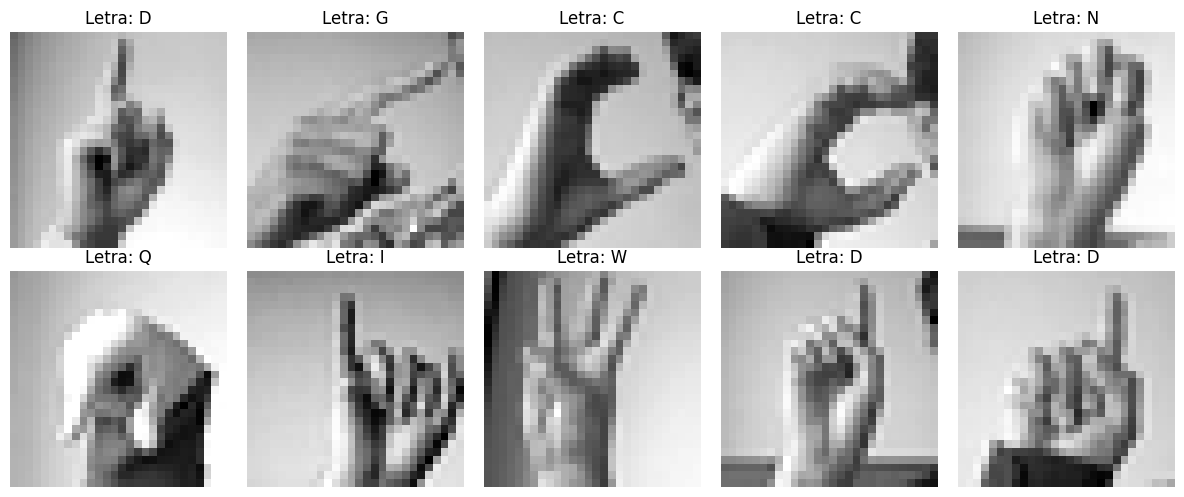

In [316]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    imagen = train_df.iloc[i, 1:].values.reshape(28, 28)
    label = train_df.iloc[i]["label"]

    ax.imshow(imagen, cmap="gray")
    ax.set_title(f"Letra: {letras[label]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [317]:
import numpy as np

print("Clases en train:", np.unique(y_train))
print("Cantidad de clases en train:", len(np.unique(y_train)))

print("Clases en validation:", np.unique(y_val))
print("Cantidad de clases en validation:", len(np.unique(y_val)))

print("Clases en test:", np.unique(y_test))
print("Cantidad de clases en test:", len(np.unique(y_test)))

Clases en train: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Cantidad de clases en train: 24
Clases en validation: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Cantidad de clases en validation: 24
Clases en test: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Cantidad de clases en test: 24


In [318]:
print("Min train:", X_train.min())
print("Max train:", X_train.max())
print("Tipo:", X_train.dtype)

Min train: 0.0
Max train: 1.0
Tipo: float32


## 4. Modelo MLP de referencia

Se implementa una red neuronal multicapa (MLP) como configuración inicial para establecer una línea base y posteriormente realizar experimentos controlados sobre sus funciones, hiperparámetros y arquitectura.

Una MLP procesa la imagen convirtiéndola en un vector de características mediante una capa `Flatten`. Esto permite clasificar las imágenes utilizando capas densamente conectadas, aunque no conserva explícitamente la estructura espacial bidimensional de la imagen.

La arquitectura inicial contiene:

- una capa `Flatten` para transformar la imagen de 28×28 píxeles en un vector de 784 valores,
- una capa densa de 256 neuronas con activación ReLU,
- una segunda capa densa de 128 neuronas con activación ReLU,
- una capa de salida de 24 neuronas con activación Softmax.

A partir de esta configuración se evaluarán distintas alternativas para seleccionar la MLP final.

In [319]:
from tensorflow.keras import models, layers
import tensorflow as tf

modelo_mlp = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),

    layers.Dense(24, activation="softmax")
])

modelo_mlp.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo_mlp.summary()

Model: "sequential_84"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_83 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_235 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_236 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_237 (Dense)               │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,952 (925.59 KB)

 Trainable params: 236,952 (925.59 KB)

 Non-trainable params: 0 (0.00 B)

### 4.1 Entrenamiento de la MLP

Para mantener condiciones comparables con los experimentos posteriores, la MLP se entrena utilizando:

- optimizador Adam,
- learning rate = 0.001,
- batch size = 32,
- 5 épocas,
- función de pérdida `sparse_categorical_crossentropy`.

Se utiliza un horizonte de **5 épocas** para mantener un presupuesto de entrenamiento común entre los experimentos y permitir una comparación consistente de la velocidad de convergencia y del rendimiento de las distintas configuraciones bajo las mismas condiciones.

In [320]:
history_mlp = modelo_mlp.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32
)

Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.3980 - loss: 1.9670 - val_accuracy: 0.5928 - val_loss: 1.2244
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6828 - loss: 0.9880 - val_accuracy: 0.7365 - val_loss: 0.7740
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7957 - loss: 0.6370 - val_accuracy: 0.8284 - val_loss: 0.5063
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8732 - loss: 0.4055 - val_accuracy: 0.8862 - val_loss: 0.3504
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9213 - loss: 0.2614 - val_accuracy: 0.9361 - val_loss: 0.2241


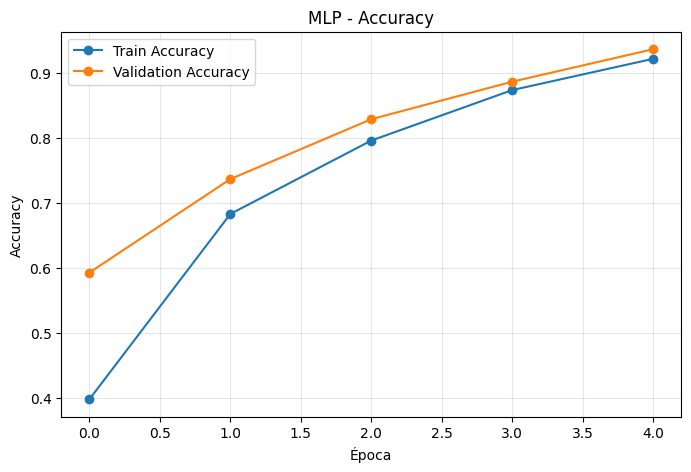

In [321]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_mlp.history["accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    history_mlp.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("MLP - Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

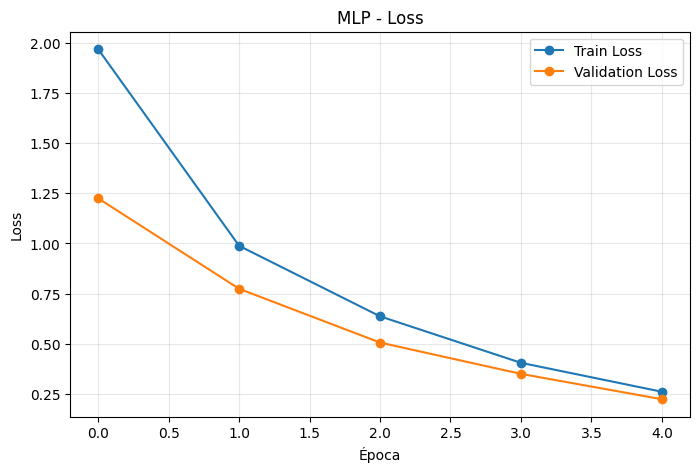

In [322]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_mlp.history["loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    history_mlp.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("MLP - Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 4.2 Análisis de la MLP

La MLP demuestra que es posible aprender el problema utilizando únicamente capas densamente conectadas.

Durante las cinco épocas, la accuracy de validación aumentó progresivamente hasta aproximadamente un 93,6%, mientras que la pérdida disminuyó de forma constante.

No se observan señales claras de sobreajuste durante este entrenamiento. Sin embargo, el modelo todavía se encontraba en proceso de convergencia al finalizar la quinta época.

Comparado con los resultados posteriores de la CNN, la MLP necesita más tiempo para alcanzar valores elevados de accuracy. Una posible explicación es que la capa `Flatten` transforma cada imagen en un vector de 784 valores, sin conservar explícitamente las relaciones espaciales entre píxeles vecinos.

Las capas convolucionales, en cambio, están diseñadas para extraer patrones locales de las imágenes, lo que resulta especialmente adecuado para reconocer formas, bordes y configuraciones de los dedos.

## 5. Comparación de funciones de activación

Para analizar el efecto de distintas funciones de activación en las capas ocultas, se comparan tres configuraciones de una misma arquitectura MLP:

- ReLU
- Tanh
- Sigmoid

En todos los casos se mantiene constante:

- la arquitectura,
- el optimizador Adam,
- learning rate = 0.001,
- batch size = 32,
- función de pérdida `sparse_categorical_crossentropy`,
- 5 épocas.

De esta forma, la única variable modificada es la función de activación.

In [323]:
def crear_mlp_activacion(activacion):
    modelo = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Flatten(),

        layers.Dense(256, activation=activacion),
        layers.Dense(128, activation=activacion),

        layers.Dense(24, activation="softmax")
    ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return modelo

In [324]:
tf.keras.utils.set_random_seed(42)
modelo_relu = crear_mlp_activacion("relu")

tf.keras.utils.set_random_seed(42)
modelo_tanh = crear_mlp_activacion("tanh")

tf.keras.utils.set_random_seed(42)
modelo_sigmoid = crear_mlp_activacion("sigmoid")

In [325]:
history_relu = modelo_relu.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

history_tanh = modelo_tanh.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

history_sigmoid = modelo_sigmoid.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3757 - loss: 2.0170 - val_accuracy: 0.5902 - val_loss: 1.2905
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6661 - loss: 1.0351 - val_accuracy: 0.7403 - val_loss: 0.8043
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7798 - loss: 0.6900 - val_accuracy: 0.8215 - val_loss: 0.5668
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8510 - loss: 0.4670 - val_accuracy: 0.8878 - val_loss: 0.3645
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8956 - loss: 0.3280 - val_accuracy: 0.9191 - val_loss: 0.2817
Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4647 - loss: 1.7226 - val_accuracy: 0.6897 - val_loss: 0.9920
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7532 - loss: 0.7909 - val_accuracy: 0.8478 - val_loss: 0.5223
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8646 - loss: 0.4569 - val_accuracy: 0.9137 - 

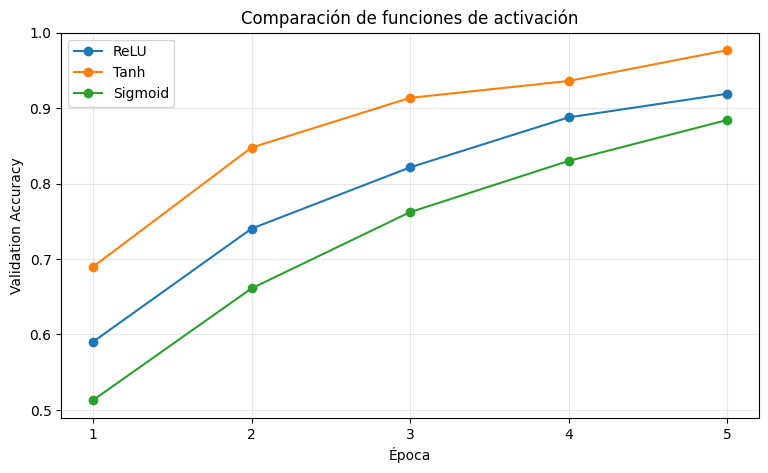

In [326]:
epocas = range(1, 6)

plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    history_relu.history["val_accuracy"],
    marker="o",
    label="ReLU"
)

plt.plot(
    epocas,
    history_tanh.history["val_accuracy"],
    marker="o",
    label="Tanh"
)

plt.plot(
    epocas,
    history_sigmoid.history["val_accuracy"],
    marker="o",
    label="Sigmoid"
)

plt.xlabel("Época")
plt.ylabel("Validation Accuracy")
plt.title("Comparación de funciones de activación")
plt.xticks(epocas)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

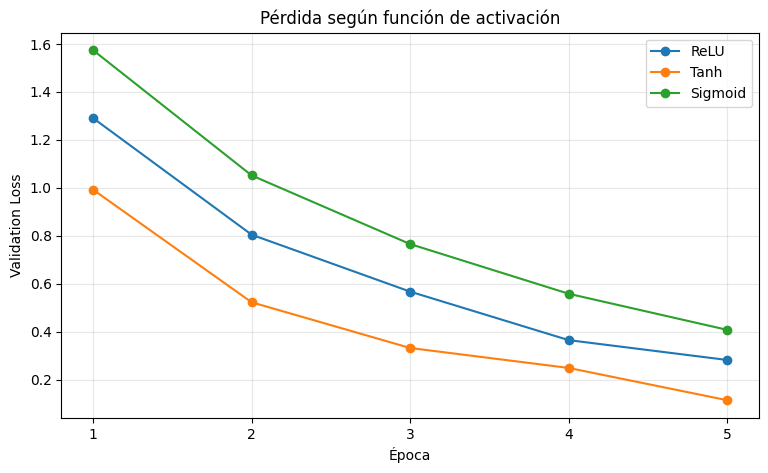

In [327]:
plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    history_relu.history["val_loss"],
    marker="o",
    label="ReLU"
)

plt.plot(
    epocas,
    history_tanh.history["val_loss"],
    marker="o",
    label="Tanh"
)

plt.plot(
    epocas,
    history_sigmoid.history["val_loss"],
    marker="o",
    label="Sigmoid"
)

plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.title("Pérdida según función de activación")
plt.xticks(epocas)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [328]:
import pandas as pd

resultados_activaciones = pd.DataFrame({
    "Activación": ["ReLU", "Tanh", "Sigmoid"],
    "Mejor Val Accuracy": [
        max(history_relu.history["val_accuracy"]),
        max(history_tanh.history["val_accuracy"]),
        max(history_sigmoid.history["val_accuracy"])
    ],
    "Mejor Val Loss": [
        min(history_relu.history["val_loss"]),
        min(history_tanh.history["val_loss"]),
        min(history_sigmoid.history["val_loss"])
    ]
})

resultados_activaciones

,Activación,Mejor Val Accuracy,Mejor Val Loss
0,ReLU,0.919140,0.281678
1,Tanh,0.976871,0.113802
2,Sigmoid,0.884356,0.407331


### 5.1 Análisis de las funciones de activación

Se compararon las funciones de activación ReLU, Tanh y Sigmoid manteniendo constantes la arquitectura, el optimizador, el learning rate, el batch size, el número de épocas y la semilla aleatoria.

Los resultados muestran diferencias claras entre las funciones evaluadas.

- **ReLU** alcanzó una mejor accuracy de validación de aproximadamente 91,91% y una pérdida mínima de 0,2817.
- **Tanh** obtuvo el mejor rendimiento, alcanzando aproximadamente 97,69% de accuracy de validación y una pérdida mínima de 0,1138.
- **Sigmoid** presentó el menor rendimiento, con aproximadamente 88,44% de accuracy y una pérdida de 0,4073.

Tanh presentó además una convergencia más rápida y consistente durante las cinco épocas evaluadas.

### Selección de la función de activación

Se selecciona **Tanh** como función de activación para las capas ocultas de la MLP.

Esta decisión se basa en que obtuvo la mayor accuracy de validación y la menor pérdida entre las configuraciones comparadas, manteniendo constantes las demás condiciones experimentales.

### 5.2 Función de activación en la capa de salida: Softmax

La capa de salida utiliza la función de activación **Softmax**, ya que el problema corresponde a una clasificación multiclase de una sola etiqueta entre 24 clases.

Softmax transforma las salidas de la red en una distribución de probabilidades, donde cada valor representa la probabilidad asociada a una clase y la suma total de las probabilidades es igual a 1.

Por ejemplo, si una imagen corresponde a la letra A, el objetivo del modelo es asignar una probabilidad mayor a la clase A que al resto de las clases.

Se utiliza Softmax en lugar de Sigmoid porque cada imagen pertenece únicamente a una de las 24 clases posibles. Sigmoid sería más apropiada en un problema multietiqueta, donde una misma entrada pudiera pertenecer simultáneamente a varias clases.

Por lo tanto, **Softmax es adecuada para la capa de salida de esta MLP**, permitiendo seleccionar como predicción final la clase con mayor probabilidad.

### 5.3 Interpretación de las funciones de activación

Aunque ReLU es ampliamente utilizada en redes profundas, en este experimento controlado Tanh obtuvo mejores resultados sobre la MLP utilizada.

Tanh transforma sus entradas al rango entre -1 y 1, lo que puede favorecer el aprendizaje en determinadas configuraciones.

Sigmoid limita las activaciones al rango entre 0 y 1 y puede presentar gradientes pequeños en regiones saturadas, lo que ayuda a explicar su convergencia más lenta observada en este experimento.

## 6. Comparación de funciones de pérdida

Para analizar el impacto de la función de pérdida se utiliza la misma arquitectura MLP con activación Tanh, que obtuvo el mejor rendimiento en el experimento anterior.

Se comparan tres configuraciones:

- `sparse_categorical_crossentropy`
- `categorical_crossentropy`
- `mean_squared_error`

Se mantienen constantes:

- arquitectura de la red,
- activación Tanh,
- optimizador Adam,
- learning rate = 0.001,
- batch size = 32,
- 5 épocas.

La diferencia entre `sparse_categorical_crossentropy` y `categorical_crossentropy` se encuentra principalmente en la representación de las etiquetas:

- Sparse utiliza etiquetas enteras.
- Categorical utiliza etiquetas codificadas mediante One-Hot Encoding.

Mean Squared Error se incluye como contraste para analizar su comportamiento en un problema de clasificación multiclase.

In [329]:
from tensorflow.keras.utils import to_categorical

y_train_onehot = to_categorical(y_train, num_classes=24)
y_val_onehot = to_categorical(y_val, num_classes=24)

print(y_train.shape)
print(y_train_onehot.shape)

(21964,)
(21964, 24)


In [330]:
def crear_mlp_loss(loss):
    modelo = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Flatten(),

        layers.Dense(256, activation="tanh"),
        layers.Dense(128, activation="tanh"),

        layers.Dense(24, activation="softmax")
    ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss=loss,
        metrics=["accuracy"]
    )

    return modelo

In [331]:
tf.keras.utils.set_random_seed(42)

modelo_sparse = crear_mlp_loss(
    "sparse_categorical_crossentropy"
)

tf.keras.utils.set_random_seed(42)

modelo_categorical = crear_mlp_loss(
    "categorical_crossentropy"
)

tf.keras.utils.set_random_seed(42)

modelo_mse = crear_mlp_loss(
    "mean_squared_error"
)

In [332]:
history_sparse = modelo_sparse.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4647 - loss: 1.7226 - val_accuracy: 0.6897 - val_loss: 0.9920
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7532 - loss: 0.7909 - val_accuracy: 0.8478 - val_loss: 0.5223
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8646 - loss: 0.4569 - val_accuracy: 0.9137 - val_loss: 0.3317
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9195 - loss: 0.2823 - val_accuracy: 0.9361 - val_loss: 0.2484
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9518 - loss: 0.1844 - val_accuracy: 0.9769 - val_loss: 0.1138


In [333]:
history_categorical = modelo_categorical.fit(
    X_train,
    y_train_onehot,
    validation_data=(X_val, y_val_onehot),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4647 - loss: 1.7226 - val_accuracy: 0.6897 - val_loss: 0.9920
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7532 - loss: 0.7909 - val_accuracy: 0.8478 - val_loss: 0.5223
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8646 - loss: 0.4569 - val_accuracy: 0.9137 - val_loss: 0.3317
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9195 - loss: 0.2823 - val_accuracy: 0.9361 - val_loss: 0.2484
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9518 - loss: 0.1844 - val_accuracy: 0.9769 - val_loss: 0.1138


In [334]:
history_mse = modelo_mse.fit(
    X_train,
    y_train_onehot,
    validation_data=(X_val, y_val_onehot),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3298 - loss: 0.0325 - val_accuracy: 0.5553 - val_loss: 0.0237
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6325 - loss: 0.0206 - val_accuracy: 0.6853 - val_loss: 0.0175
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7554 - loss: 0.0147 - val_accuracy: 0.8237 - val_loss: 0.0110
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8378 - loss: 0.0102 - val_accuracy: 0.8629 - val_loss: 0.0090
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8849 - loss: 0.0075 - val_accuracy: 0.9153 - val_loss: 0.0058


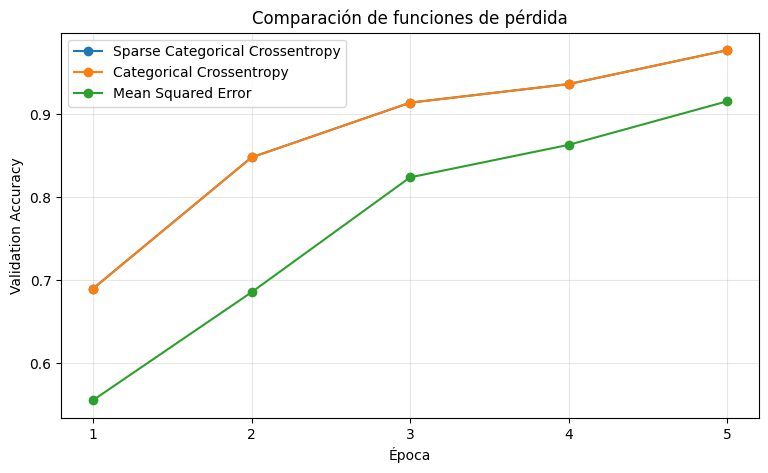

In [335]:
epocas = range(1, 6)

plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    history_sparse.history["val_accuracy"],
    marker="o",
    label="Sparse Categorical Crossentropy"
)

plt.plot(
    epocas,
    history_categorical.history["val_accuracy"],
    marker="o",
    label="Categorical Crossentropy"
)

plt.plot(
    epocas,
    history_mse.history["val_accuracy"],
    marker="o",
    label="Mean Squared Error"
)

plt.xlabel("Época")
plt.ylabel("Validation Accuracy")
plt.title("Comparación de funciones de pérdida")
plt.xticks(epocas)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

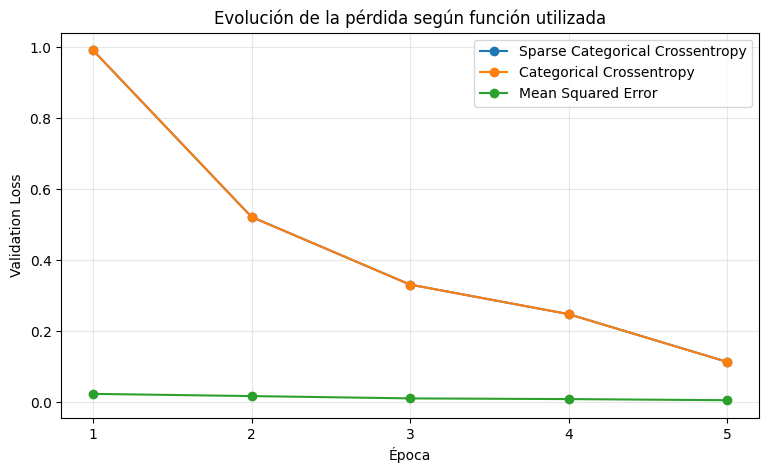

In [336]:
plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    history_sparse.history["val_loss"],
    marker="o",
    label="Sparse Categorical Crossentropy"
)

plt.plot(
    epocas,
    history_categorical.history["val_loss"],
    marker="o",
    label="Categorical Crossentropy"
)

plt.plot(
    epocas,
    history_mse.history["val_loss"],
    marker="o",
    label="Mean Squared Error"
)

plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.title("Evolución de la pérdida según función utilizada")
plt.xticks(epocas)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [337]:
resultados_loss = pd.DataFrame({
    "Función de pérdida": [
        "Sparse Categorical Crossentropy",
        "Categorical Crossentropy",
        "Mean Squared Error"
    ],
    "Mejor Val Accuracy": [
        max(history_sparse.history["val_accuracy"]),
        max(history_categorical.history["val_accuracy"]),
        max(history_mse.history["val_accuracy"])
    ],
    "Val Accuracy final": [
        history_sparse.history["val_accuracy"][-1],
        history_categorical.history["val_accuracy"][-1],
        history_mse.history["val_accuracy"][-1]
    ]
})

resultados_loss

,Función de pérdida,Mejor Val Accuracy,Val Accuracy final
0,Sparse Categorical Crossentropy,0.976871,0.976871
1,Categorical Crossentropy,0.976871,0.976871
2,Mean Squared Error,0.915316,0.915316


### 6.1 Análisis de las funciones de pérdida

Los resultados muestran que `sparse_categorical_crossentropy` y `categorical_crossentropy` presentan prácticamente el mismo rendimiento, alcanzando aproximadamente un 97,7% de accuracy de validación.

Esto es esperable, ya que ambas funciones están diseñadas para problemas de clasificación multiclase y se diferencian principalmente en la representación de las etiquetas.

En cambio, `mean_squared_error` obtuvo un rendimiento inferior, con aproximadamente un 91,5% de accuracy de validación.

Aunque los valores numéricos de MSE son menores en la gráfica de pérdida, no deben compararse directamente con los valores de cross-entropy, ya que cada función utiliza una escala diferente.

Para comparar el rendimiento entre funciones se considera principalmente la accuracy y la velocidad de convergencia.

### 6.2 Selección de la función de pérdida

Se selecciona `sparse_categorical_crossentropy` como función de pérdida para el modelo final.

La elección se justifica porque:

- el problema corresponde a clasificación multiclase,
- las etiquetas están almacenadas como valores enteros,
- obtiene el mismo rendimiento que `categorical_crossentropy`,
- evita realizar una conversión adicional a One-Hot Encoding.

Por lo tanto, `sparse_categorical_crossentropy` proporciona una solución adecuada y más simple para la representación actual de las etiquetas.

## 7. Comparación adicional: CNN de referencia

Como análisis complementario, se implementa una red neuronal convolucional sencilla para comparar su comportamiento con la MLP utilizada como modelo principal de esta evaluación.

La arquitectura utiliza:

- una primera capa convolucional con 32 filtros,
- una capa de MaxPooling,
- una segunda capa convolucional con 64 filtros,
- una segunda capa de MaxPooling,
- una capa `Flatten`,
- una capa densa de 128 neuronas,
- una capa de salida de 24 neuronas con activación `Softmax`.

Las capas convolucionales permiten extraer patrones locales de las imágenes, como bordes, formas y configuraciones de los dedos.

La capa `Softmax` se utiliza porque el problema corresponde a una clasificación multiclase de una sola etiqueta entre 24 posibles clases.

In [338]:
import tensorflow as tf
from tensorflow.keras import layers, models

modelo_base = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dense(24, activation="softmax")
])

modelo_base.summary()

Model: "sequential_91"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_90 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_257 (Dense)               │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,840 (886.09 KB)

 Trainable params: 226,840 (886.09 KB)

 Non-trainable params: 0 (0.00 B)

### 7.1 Configuración de entrenamiento

El modelo se entrena utilizando:

- **Optimizador:** Adam
- **Learning rate:** 0.001
- **Función de pérdida:** `sparse_categorical_crossentropy`
- **Batch size:** 32
- **Épocas iniciales:** 15

Se utiliza `sparse_categorical_crossentropy` porque las etiquetas se encuentran representadas como valores enteros entre 0 y 23, sin codificación one-hot.

El optimizador Adam se selecciona como configuración inicial por su capacidad de adaptar la magnitud de las actualizaciones de los pesos durante el entrenamiento.

In [339]:
modelo_base.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [340]:
history_base = modelo_base.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32
)

Epoch 1/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.7175 - loss: 0.9728 - val_accuracy: 0.9592 - val_loss: 0.1742
Epoch 2/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 41s 36ms/step - accuracy: 0.9885 - loss: 0.0618 - val_accuracy: 0.9989 - val_loss: 0.0195
Epoch 3/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.9989 - loss: 0.0117 - val_accuracy: 1.0000 - val_loss: 0.0046
Epoch 4/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.9999 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 5/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 9.7177e-04
Epoch 6/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - accuracy: 1.0000 - loss: 6.3269e-04 - val_accuracy: 1.0000 - val_loss: 5.9016e-04
Epoch 7/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 25s 37ms/step - accuracy: 1.0000 - loss: 3.7595e-04 - val_accuracy: 1.0000 - val_loss: 3.7490e-04
Epoch 8/15
687/687 ━━━━━━━━━━━━━━━━━━━━ 26s 38ms/step - accuracy: 0.98

### 7.2 Curvas de aprendizaje

Se analizan las curvas de `accuracy` y `loss` tanto para entrenamiento como para validación.

El objetivo es observar:

- velocidad de convergencia,
- estabilidad del entrenamiento,
- posibles señales de overfitting,
- diferencia entre entrenamiento y validación.

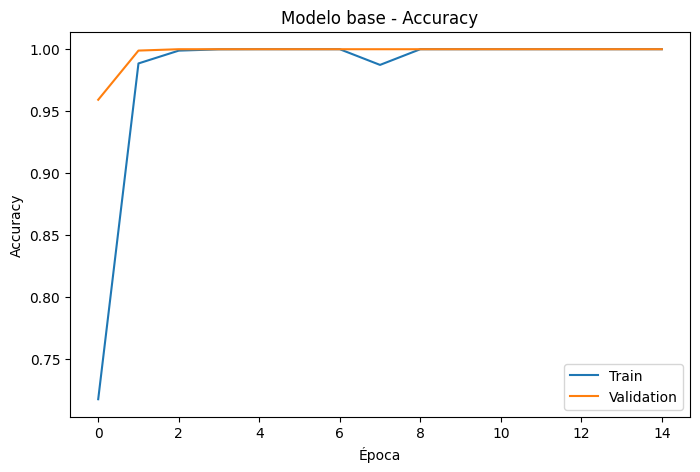

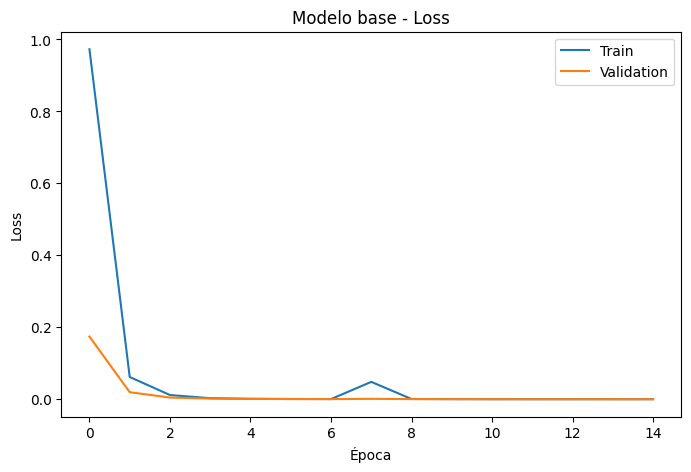

In [341]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_base.history["accuracy"], label="Train")
plt.plot(history_base.history["val_accuracy"], label="Validation")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Modelo base - Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_base.history["loss"], label="Train")
plt.plot(history_base.history["val_loss"], label="Validation")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Modelo base - Loss")
plt.legend()
plt.show()

### 7.3 Análisis del modelo base

El modelo alcanza rápidamente valores de accuracy cercanos al 100% tanto en entrenamiento como en validación.

Se observa una oscilación puntual durante una de las épocas, pero el modelo recupera inmediatamente su rendimiento en las épocas siguientes.

Además, la convergencia ocurre muy temprano, por lo que entrenar durante 15 épocas no parece aportar mejoras relevantes después de las primeras épocas.

Este resultado también respalda la decisión de mantener un horizonte de 5 épocas en los experimentos posteriores, facilitando comparaciones controladas entre configuraciones.

In [342]:
for epoca in range(len(history_base.history["accuracy"])):
    print(
        f"Época {epoca + 1:02d} | "
        f"Train Acc: {history_base.history['accuracy'][epoca]:.4f} | "
        f"Val Acc: {history_base.history['val_accuracy'][epoca]:.4f} | "
        f"Train Loss: {history_base.history['loss'][epoca]:.4f} | "
        f"Val Loss: {history_base.history['val_loss'][epoca]:.4f}"
    )

Época 01 | Train Acc: 0.7175 | Val Acc: 0.9592 | Train Loss: 0.9728 | Val Loss: 0.1742
Época 02 | Train Acc: 0.9885 | Val Acc: 0.9989 | Train Loss: 0.0618 | Val Loss: 0.0195
Época 03 | Train Acc: 0.9989 | Val Acc: 1.0000 | Train Loss: 0.0117 | Val Loss: 0.0046
Época 04 | Train Acc: 0.9999 | Val Acc: 1.0000 | Train Loss: 0.0029 | Val Loss: 0.0018
Época 05 | Train Acc: 1.0000 | Val Acc: 1.0000 | Train Loss: 0.0012 | Val Loss: 0.0010
Época 06 | Train Acc: 1.0000 | Val Acc: 1.0000 | Train Loss: 0.0006 | Val Loss: 0.0006
Época 07 | Train Acc: 1.0000 | Val Acc: 1.0000 | Train Loss: 0.0004 | Val Loss: 0.0004
Época 08 | Train Acc: 0.9873 | Val Acc: 1.0000 | Train Loss: 0.0482 | Val Loss: 0.0011
Época 09 | Train Acc: 1.0000 | Val Acc: 1.0000 | Train Loss: 0.0006 | Val Loss: 0.0004
Época 10 | Train Acc: 1.0000 | Val Acc: 1.0000 | Train Loss: 0.0003 | Val Loss: 0.0002
Época 11 | Train Acc: 1.0000 | Val Acc: 1.0000 | Train Loss: 0.0001 | Val Loss: 0.0002
Época 12 | Train Acc: 1.0000 | Val Acc: 1.0

In [343]:
import numpy as np

mejor_epoca = np.argmax(history_base.history["val_accuracy"])

print("Mejor época:", mejor_epoca + 1)
print(
    "Mejor validation accuracy:",
    history_base.history["val_accuracy"][mejor_epoca]
)
print(
    "Validation loss:",
    history_base.history["val_loss"][mejor_epoca]
)

Mejor época: 3
Mejor validation accuracy: 1.0
Validation loss: 0.0046148281544446945


### 7.4 Comparación entre MLP y CNN

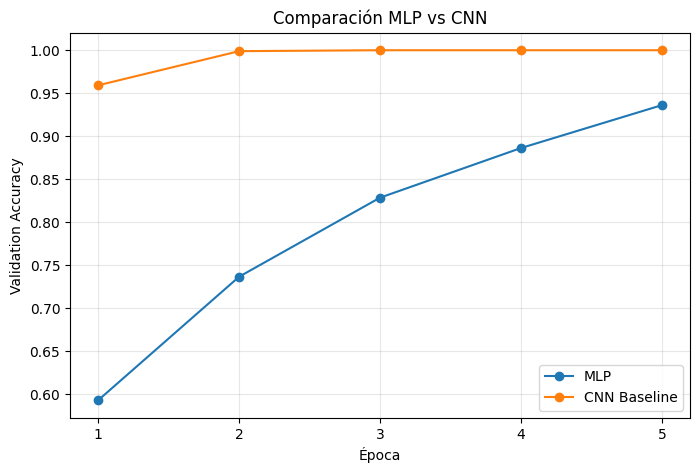

In [344]:
epocas = range(1, 6)

plt.figure(figsize=(8, 5))

plt.plot(
    epocas,
    history_mlp.history["val_accuracy"],
    marker="o",
    label="MLP"
)

plt.plot(
    epocas,
    history_base.history["val_accuracy"][:5],
    marker="o",
    label="CNN Baseline"
)

plt.xlabel("Época")
plt.ylabel("Validation Accuracy")
plt.title("Comparación MLP vs CNN")
plt.xticks(epocas)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

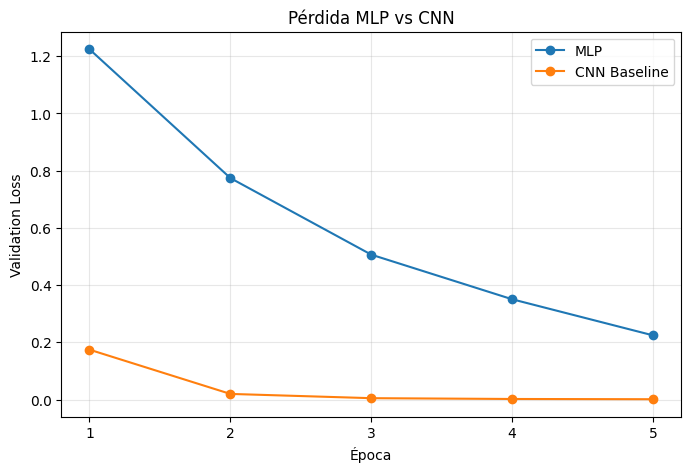

In [345]:
plt.figure(figsize=(8, 5))

plt.plot(
    epocas,
    history_mlp.history["val_loss"],
    marker="o",
    label="MLP"
)

plt.plot(
    epocas,
    history_base.history["val_loss"][:5],
    marker="o",
    label="CNN Baseline"
)

plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.title("Pérdida MLP vs CNN")
plt.xticks(epocas)
plt.legend()
plt.grid(alpha=0.3)
plt.show()



La comparación muestra que ambas arquitecturas son capaces de aprender el problema, pero presentan comportamientos distintos.

La MLP mejora de forma progresiva y alcanza aproximadamente un 93,6% de accuracy de validación después de cinco épocas.

La CNN, en cambio, alcanza valores cercanos al 100% en aproximadamente dos o tres épocas y presenta una pérdida considerablemente menor.

La principal diferencia está en la forma en que procesan la imagen:

- La MLP utiliza `Flatten`, transformando la imagen completa en un vector.
- La CNN conserva relaciones espaciales locales mediante filtros convolucionales.

Esto permite que la CNN aprenda patrones como bordes, contornos y configuraciones de los dedos de forma más eficiente.

Esta comparación se incluye únicamente como análisis complementario para observar las diferencias entre una MLP y una arquitectura especializada en imágenes.

La CNN presenta una convergencia más rápida en este conjunto de validación, pero **no corresponde al modelo principal de esta evaluación**. Los experimentos posteriores continúan centrados en la MLP, de acuerdo con los objetivos definidos para el trabajo.

## Ajuste de hiperparámetros de la MLP

Una vez seleccionadas las funciones más adecuadas para la MLP, se analizan distintos hiperparámetros manteniendo controladas las demás variables.

La configuración utilizada como referencia es:

- Arquitectura: Flatten → Dense(256) → Dense(128) → Dense(24)
- Activación oculta: Tanh
- Activación de salida: Softmax
- Función de pérdida: Sparse Categorical Crossentropy
- Optimizador: Adam
- Batch size: 32
- Épocas: 5

### Experimento: Learning Rate

Se comparan tres tasas de aprendizaje:

- 0.0001
- 0.001
- 0.01

El resto de la configuración permanece constante, por lo que la única variable modificada es el learning rate.

El objetivo es analizar cómo la magnitud de las actualizaciones de los pesos afecta la velocidad de convergencia y el rendimiento de validación.

In [346]:
def crear_mlp_lr(learning_rate):
    modelo = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Flatten(),

        layers.Dense(256, activation="tanh"),
        layers.Dense(128, activation="tanh"),

        layers.Dense(24, activation="softmax")
    ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return modelo

In [347]:
tf.keras.utils.set_random_seed(42)
mlp_lr_0001 = crear_mlp_lr(0.0001)

tf.keras.utils.set_random_seed(42)
mlp_lr_001 = crear_mlp_lr(0.001)

tf.keras.utils.set_random_seed(42)
mlp_lr_01 = crear_mlp_lr(0.01)

In [348]:
history_mlp_lr_0001 = mlp_lr_0001.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

history_mlp_lr_001 = mlp_lr_001.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

history_mlp_lr_01 = mlp_lr_01.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3401 - loss: 2.3725 - val_accuracy: 0.5008 - val_loss: 1.8028
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6047 - loss: 1.5086 - val_accuracy: 0.6469 - val_loss: 1.3028
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7011 - loss: 1.1463 - val_accuracy: 0.7128 - val_loss: 1.0372
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7606 - loss: 0.9264 - val_accuracy: 0.7645 - val_loss: 0.8572
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8046 - loss: 0.7695 - val_accuracy: 0.8101 - val_loss: 0.7204
Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.4647 - loss: 1.7226 - val_accuracy: 0.6897 - val_loss: 0.9920
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7532 - loss: 0.7909 - val_accuracy: 0.8478 - val_loss: 0.5223
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8646 - loss: 0.4569 - val_accuracy: 0.9137 - v

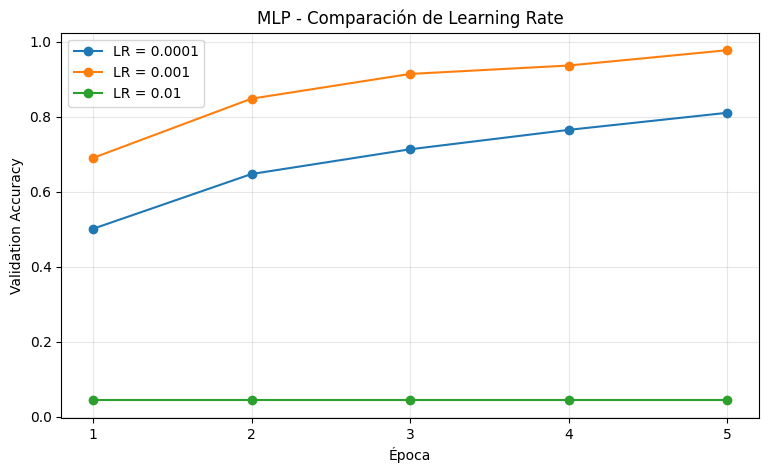

In [349]:
epocas = range(1, 6)

plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    history_mlp_lr_0001.history["val_accuracy"],
    marker="o",
    label="LR = 0.0001"
)

plt.plot(
    epocas,
    history_mlp_lr_001.history["val_accuracy"],
    marker="o",
    label="LR = 0.001"
)

plt.plot(
    epocas,
    history_mlp_lr_01.history["val_accuracy"],
    marker="o",
    label="LR = 0.01"
)

plt.xlabel("Época")
plt.ylabel("Validation Accuracy")
plt.title("MLP - Comparación de Learning Rate")
plt.xticks(epocas)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

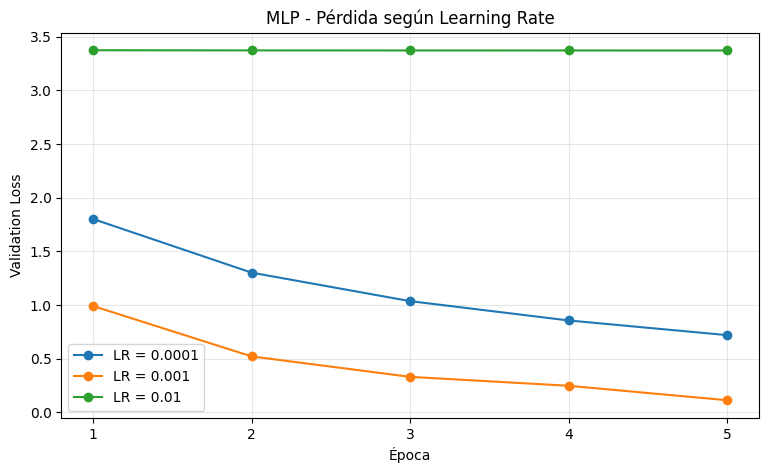

In [350]:
plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    history_mlp_lr_0001.history["val_loss"],
    marker="o",
    label="LR = 0.0001"
)

plt.plot(
    epocas,
    history_mlp_lr_001.history["val_loss"],
    marker="o",
    label="LR = 0.001"
)

plt.plot(
    epocas,
    history_mlp_lr_01.history["val_loss"],
    marker="o",
    label="LR = 0.01"
)

plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.title("MLP - Pérdida según Learning Rate")
plt.xticks(epocas)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [351]:
resultados_lr_mlp = pd.DataFrame({
    "Learning Rate": [0.0001, 0.001, 0.01],

    "Mejor Val Accuracy": [
        max(history_mlp_lr_0001.history["val_accuracy"]),
        max(history_mlp_lr_001.history["val_accuracy"]),
        max(history_mlp_lr_01.history["val_accuracy"])
    ],

    "Mejor Val Loss": [
        min(history_mlp_lr_0001.history["val_loss"]),
        min(history_mlp_lr_001.history["val_loss"]),
        min(history_mlp_lr_01.history["val_loss"])
    ]
})

resultados_lr_mlp

,Learning Rate,Mejor Val Accuracy,Mejor Val Loss
0,0.0001,0.810053,0.720423
1,0.0010,0.976871,0.113802
2,0.0100,0.043890,3.372779


### Análisis del Learning Rate

Los resultados muestran que la tasa de aprendizaje tiene un impacto importante en la velocidad y estabilidad del entrenamiento.

Con un `learning_rate = 0.0001`, el modelo mejora progresivamente, pero presenta una convergencia lenta. Después de cinco épocas alcanza aproximadamente un 81% de accuracy de validación, lo que indica que probablemente requeriría una mayor cantidad de épocas para alcanzar un mejor desempeño.

Con `learning_rate = 0.001`, la MLP presenta el mejor comportamiento, alcanzando aproximadamente un 97,69% de accuracy de validación y la menor pérdida entre las configuraciones útiles evaluadas.

En cambio, con `learning_rate = 0.01`, el modelo no logra converger correctamente. Su accuracy permanece cercana al 4%, valor próximo al comportamiento esperado de una clasificación prácticamente aleatoria entre 24 clases.

Esto demuestra que una tasa de aprendizaje demasiado baja puede ralentizar la convergencia, mientras que una tasa demasiado alta puede impedir que el proceso de optimización encuentre una solución estable.

### Selección del Learning Rate

Se selecciona un `learning_rate = 0.001` para los siguientes experimentos.

Este valor presentó el mejor equilibrio entre velocidad de convergencia, accuracy de validación y reducción de la función de pérdida.

Por lo tanto, los siguientes ajustes de hiperparámetros mantendrán fijo este valor para realizar comparaciones controladas.

### Experimento: Batch Size

Una vez seleccionado `learning_rate = 0.001`, se analiza el efecto del tamaño de batch sobre el entrenamiento de la MLP.

Se comparan tres configuraciones:

- Batch size = 16
- Batch size = 32
- Batch size = 64

Se mantienen constantes:

- Arquitectura: Flatten → Dense(256) → Dense(128) → Dense(24)
- Activación oculta: Tanh
- Activación de salida: Softmax
- Función de pérdida: Sparse Categorical Crossentropy
- Optimizador: Adam
- Learning rate = 0.001
- Épocas = 5

De esta forma, la única variable modificada es el tamaño del batch.

In [352]:
def crear_mlp_batch():
    modelo = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Flatten(),

        layers.Dense(256, activation="tanh"),
        layers.Dense(128, activation="tanh"),

        layers.Dense(24, activation="softmax")
    ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return modelo

In [353]:
tf.keras.utils.set_random_seed(42)
mlp_batch16 = crear_mlp_batch()

tf.keras.utils.set_random_seed(42)
mlp_batch32 = crear_mlp_batch()

tf.keras.utils.set_random_seed(42)
mlp_batch64 = crear_mlp_batch()

In [354]:
history_mlp_batch16 = mlp_batch16.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=16,
    verbose=1
)

history_mlp_batch32 = mlp_batch32.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

history_mlp_batch64 = mlp_batch64.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64,
    verbose=1
)

Epoch 1/5
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.4546 - loss: 1.7275 - val_accuracy: 0.6862 - val_loss: 0.9602
Epoch 2/5
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7401 - loss: 0.8044 - val_accuracy: 0.8275 - val_loss: 0.5518
Epoch 3/5
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8569 - loss: 0.4591 - val_accuracy: 0.9026 - val_loss: 0.3321
Epoch 4/5
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9127 - loss: 0.2905 - val_accuracy: 0.9006 - val_loss: 0.3197
Epoch 5/5
1373/1373 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9432 - loss: 0.1979 - val_accuracy: 0.8931 - val_loss: 0.3131
Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4647 - loss: 1.7226 - val_accuracy: 0.6897 - val_loss: 0.9920
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7532 - loss: 0.7909 - val_accuracy: 0.8478 - val_loss: 0.5223
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8646 - loss: 0.4569 - val_accuracy:

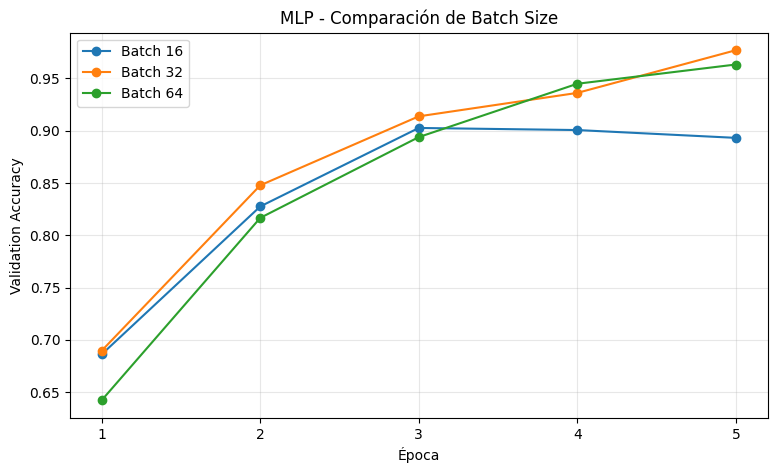

In [355]:
epocas = range(1, 6)

plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    history_mlp_batch16.history["val_accuracy"],
    marker="o",
    label="Batch 16"
)

plt.plot(
    epocas,
    history_mlp_batch32.history["val_accuracy"],
    marker="o",
    label="Batch 32"
)

plt.plot(
    epocas,
    history_mlp_batch64.history["val_accuracy"],
    marker="o",
    label="Batch 64"
)

plt.xlabel("Época")
plt.ylabel("Validation Accuracy")
plt.title("MLP - Comparación de Batch Size")
plt.xticks(epocas)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

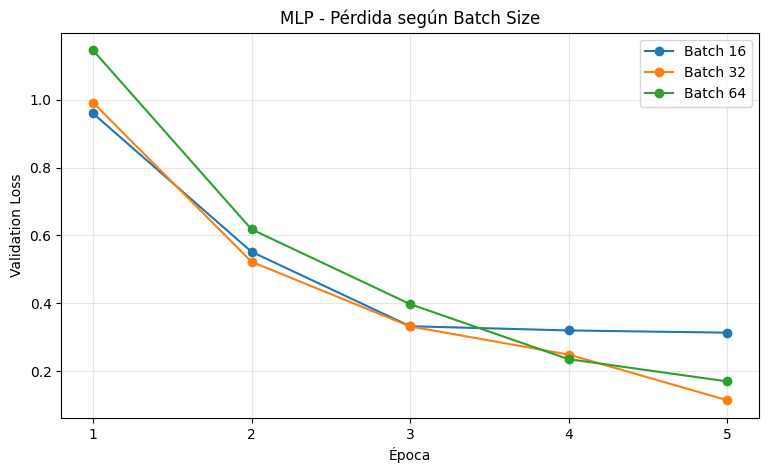

In [356]:
plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    history_mlp_batch16.history["val_loss"],
    marker="o",
    label="Batch 16"
)

plt.plot(
    epocas,
    history_mlp_batch32.history["val_loss"],
    marker="o",
    label="Batch 32"
)

plt.plot(
    epocas,
    history_mlp_batch64.history["val_loss"],
    marker="o",
    label="Batch 64"
)

plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.title("MLP - Pérdida según Batch Size")
plt.xticks(epocas)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [357]:
resultados_batch_mlp = pd.DataFrame({
    "Batch Size": [16, 32, 64],

    "Mejor Val Accuracy": [
        max(history_mlp_batch16.history["val_accuracy"]),
        max(history_mlp_batch32.history["val_accuracy"]),
        max(history_mlp_batch64.history["val_accuracy"])
    ],

    "Mejor Val Loss": [
        min(history_mlp_batch16.history["val_loss"]),
        min(history_mlp_batch32.history["val_loss"]),
        min(history_mlp_batch64.history["val_loss"])
    ]
})

resultados_batch_mlp

,Batch Size,Mejor Val Accuracy,Mejor Val Loss
0,16,0.902568,0.313147
1,32,0.976871,0.113802
2,64,0.963213,0.169365


### Análisis del Batch Size

Los resultados muestran que el tamaño de batch afecta tanto la velocidad de convergencia como el desempeño final de la MLP.

Con `batch_size = 16`, el modelo mejora rápidamente durante las primeras épocas, pero posteriormente se estabiliza y presenta una ligera disminución en la accuracy de validación. Su mejor resultado fue aproximadamente 90,26%.

Con `batch_size = 64`, la convergencia inicial fue más lenta, aunque el modelo continuó mejorando hasta alcanzar aproximadamente 96,32% de accuracy de validación.

El mejor comportamiento se obtuvo con `batch_size = 32`, alcanzando aproximadamente 97,69% de accuracy de validación y la menor pérdida entre las configuraciones evaluadas.

Esto muestra que un batch más pequeño no necesariamente produce un mejor resultado final, y que el tamaño del batch debe ajustarse experimentalmente según el comportamiento del modelo.

### Selección del Batch Size

Se selecciona `batch_size = 32` para los siguientes experimentos.

Esta configuración presentó el mejor equilibrio entre convergencia, accuracy de validación y reducción de la función de pérdida.

A partir de este punto se mantendrán constantes:

- Learning rate = 0.001
- Batch size = 32
- Activación oculta = Tanh
- Activación de salida = Softmax
- Loss = Sparse Categorical Crossentropy
- Optimizador = Adam

### Experimento: Regularización con Dropout

Se analiza el efecto de la técnica de regularización Dropout sobre la MLP seleccionada.

Se comparan tres configuraciones:

- Sin Dropout
- Dropout = 0.1
- Dropout = 0.3

Se mantienen constantes:

- Arquitectura base de la MLP
- Activación oculta = Tanh
- Activación de salida = Softmax
- Learning rate = 0.001
- Batch size = 32
- Optimizador = Adam
- Función de pérdida = Sparse Categorical Crossentropy
- Épocas = 5

Dropout desactiva aleatoriamente una proporción de neuronas durante el entrenamiento, con el objetivo de reducir la dependencia excesiva entre neuronas y favorecer la capacidad de generalización.

La única variable modificada en este experimento es la intensidad de Dropout.

In [358]:
def crear_mlp_dropout(dropout_rate=None):
    modelo = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Flatten(),

        layers.Dense(256, activation="tanh")
    ])

    if dropout_rate is not None:
        modelo.add(layers.Dropout(dropout_rate))

    modelo.add(layers.Dense(128, activation="tanh"))

    if dropout_rate is not None:
        modelo.add(layers.Dropout(dropout_rate))

    modelo.add(layers.Dense(24, activation="softmax"))

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return modelo

In [359]:
tf.keras.utils.set_random_seed(42)
mlp_sin_dropout = crear_mlp_dropout()

tf.keras.utils.set_random_seed(42)
mlp_dropout01 = crear_mlp_dropout(0.1)

tf.keras.utils.set_random_seed(42)
mlp_dropout03 = crear_mlp_dropout(0.3)

In [360]:
history_mlp_sin_dropout = mlp_sin_dropout.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

history_mlp_dropout01 = mlp_dropout01.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

history_mlp_dropout03 = mlp_dropout03.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4647 - loss: 1.7226 - val_accuracy: 0.6897 - val_loss: 0.9920
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7532 - loss: 0.7909 - val_accuracy: 0.8478 - val_loss: 0.5223
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8646 - loss: 0.4569 - val_accuracy: 0.9137 - val_loss: 0.3317
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9195 - loss: 0.2823 - val_accuracy: 0.9361 - val_loss: 0.2484
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9518 - loss: 0.1844 - val_accuracy: 0.9769 - val_loss: 0.1138
Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4074 - loss: 1.9069 - val_accuracy: 0.6769 - val_loss: 1.0649
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6833 - loss: 0.9819 - val_accuracy: 0.8019 - val_loss: 0.6563
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7868 - loss: 0.6609 - val_accuracy: 0.8565 - v

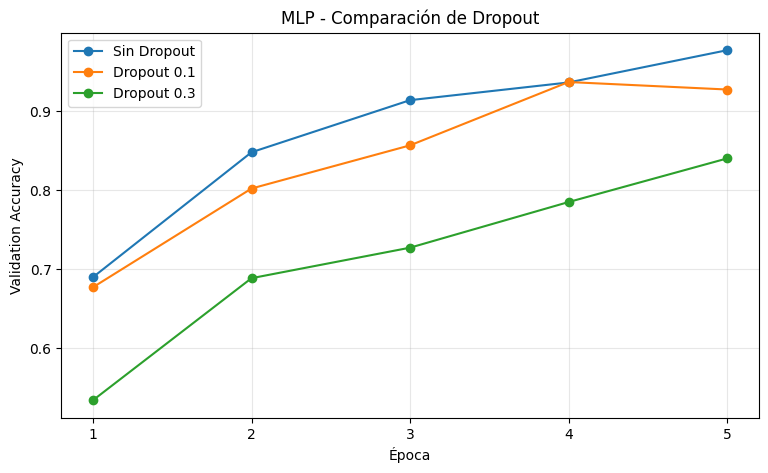

In [361]:
epocas = range(1, 6)

plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    history_mlp_sin_dropout.history["val_accuracy"],
    marker="o",
    label="Sin Dropout"
)

plt.plot(
    epocas,
    history_mlp_dropout01.history["val_accuracy"],
    marker="o",
    label="Dropout 0.1"
)

plt.plot(
    epocas,
    history_mlp_dropout03.history["val_accuracy"],
    marker="o",
    label="Dropout 0.3"
)

plt.xlabel("Época")
plt.ylabel("Validation Accuracy")
plt.title("MLP - Comparación de Dropout")
plt.xticks(epocas)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

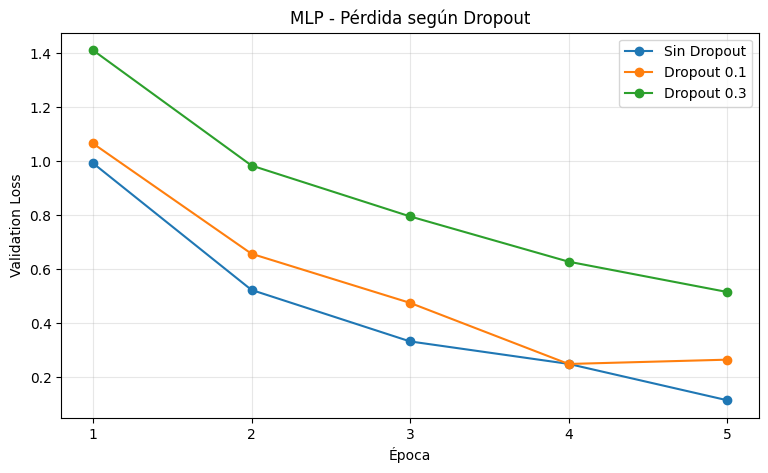

In [362]:
plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    history_mlp_sin_dropout.history["val_loss"],
    marker="o",
    label="Sin Dropout"
)

plt.plot(
    epocas,
    history_mlp_dropout01.history["val_loss"],
    marker="o",
    label="Dropout 0.1"
)

plt.plot(
    epocas,
    history_mlp_dropout03.history["val_loss"],
    marker="o",
    label="Dropout 0.3"
)

plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.title("MLP - Pérdida según Dropout")
plt.xticks(epocas)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [363]:
resultados_dropout_mlp = pd.DataFrame({
    "Configuración": [
        "Sin Dropout",
        "Dropout 0.1",
        "Dropout 0.3"
    ],

    "Mejor Val Accuracy": [
        max(history_mlp_sin_dropout.history["val_accuracy"]),
        max(history_mlp_dropout01.history["val_accuracy"]),
        max(history_mlp_dropout03.history["val_accuracy"])
    ],

    "Mejor Val Loss": [
        min(history_mlp_sin_dropout.history["val_loss"]),
        min(history_mlp_dropout01.history["val_loss"]),
        min(history_mlp_dropout03.history["val_loss"])
    ]
})

resultados_dropout_mlp

,Configuración,Mejor Val Accuracy,Mejor Val Loss
0,Sin Dropout,0.976871,0.113802
1,Dropout 0.1,0.936624,0.248092
2,Dropout 0.3,0.839920,0.514811


### Análisis de Dropout

Los resultados muestran que la incorporación de Dropout redujo el rendimiento de la MLP durante las cinco épocas evaluadas.

El modelo sin Dropout obtuvo el mejor desempeño, alcanzando aproximadamente un 97,69% de accuracy de validación y la menor pérdida.

Con `Dropout = 0.1`, la convergencia fue más lenta y el mejor accuracy de validación disminuyó a aproximadamente 93,66%.

Con `Dropout = 0.3`, el efecto fue aún más marcado, alcanzando aproximadamente 83,99% de accuracy de validación.

Esto indica que, bajo las condiciones evaluadas, la regularización mediante Dropout reduce demasiado la capacidad de aprendizaje de la red durante las primeras cinco épocas.

### Selección de regularización

Para la configuración final se decide no utilizar Dropout.

Aunque Dropout puede ayudar a reducir sobreajuste en determinadas redes, en este experimento no se observaron mejoras en validación.

El modelo sin Dropout obtuvo tanto la mayor accuracy como la menor pérdida de validación.

Por lo tanto, se mantiene la arquitectura sin Dropout para los siguientes experimentos.

### Experimento: comparación de optimizadores

Una vez seleccionada la configuración sin Dropout, se analiza el efecto del optimizador sobre el entrenamiento de la MLP.

Se comparan tres optimizadores:

- Adam
- RMSprop
- SGD

Para realizar un experimento controlado se mantienen constantes:

- Arquitectura: Flatten → Dense(256) → Dense(128) → Dense(24)
- Activación oculta: Tanh
- Activación de salida: Softmax
- Función de pérdida: Sparse Categorical Crossentropy
- Learning rate = 0.001
- Batch size = 32
- Sin Dropout
- Épocas = 5

De esta forma, la única variable modificada es el algoritmo utilizado para actualizar los pesos.

In [364]:
def crear_mlp_optimizador(optimizador):
    modelo = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Flatten(),

        layers.Dense(256, activation="tanh"),
        layers.Dense(128, activation="tanh"),

        layers.Dense(24, activation="softmax")
    ])

    modelo.compile(
        optimizer=optimizador,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return modelo

In [365]:
tf.keras.utils.set_random_seed(42)

mlp_adam = crear_mlp_optimizador(
    tf.keras.optimizers.Adam(learning_rate=0.001)
)

tf.keras.utils.set_random_seed(42)

mlp_rmsprop = crear_mlp_optimizador(
    tf.keras.optimizers.RMSprop(learning_rate=0.001)
)

tf.keras.utils.set_random_seed(42)

mlp_sgd = crear_mlp_optimizador(
    tf.keras.optimizers.SGD(learning_rate=0.001)
)

In [366]:
history_mlp_adam = mlp_adam.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

history_mlp_rmsprop = mlp_rmsprop.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

history_mlp_sgd = mlp_sgd.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4647 - loss: 1.7226 - val_accuracy: 0.6897 - val_loss: 0.9920
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7532 - loss: 0.7909 - val_accuracy: 0.8478 - val_loss: 0.5223
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8646 - loss: 0.4569 - val_accuracy: 0.9137 - val_loss: 0.3317
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9195 - loss: 0.2823 - val_accuracy: 0.9361 - val_loss: 0.2484
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9518 - loss: 0.1844 - val_accuracy: 0.9769 - val_loss: 0.1138
Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.3354 - loss: 2.1218 - val_accuracy: 0.5261 - val_loss: 1.4632
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6135 - loss: 1.1910 - val_accuracy: 0.6318 - val_loss: 1.1021
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7545 - loss: 0.7737 - val_accuracy: 0.7935 - 

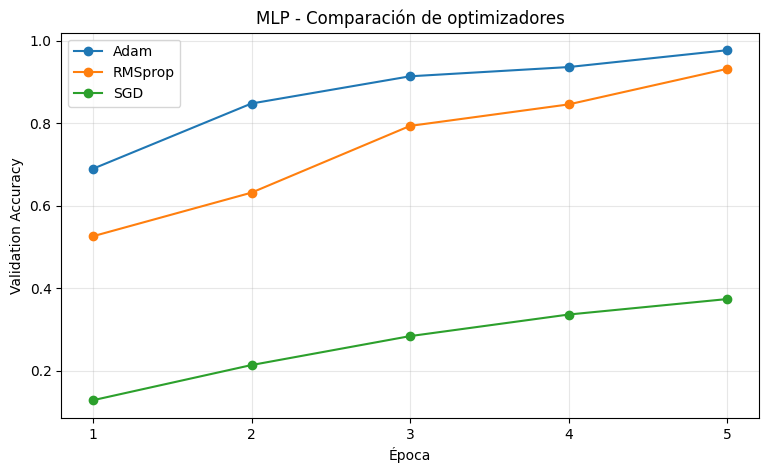

In [367]:
epocas = range(1, 6)

plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    history_mlp_adam.history["val_accuracy"],
    marker="o",
    label="Adam"
)

plt.plot(
    epocas,
    history_mlp_rmsprop.history["val_accuracy"],
    marker="o",
    label="RMSprop"
)

plt.plot(
    epocas,
    history_mlp_sgd.history["val_accuracy"],
    marker="o",
    label="SGD"
)

plt.xlabel("Época")
plt.ylabel("Validation Accuracy")
plt.title("MLP - Comparación de optimizadores")
plt.xticks(epocas)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

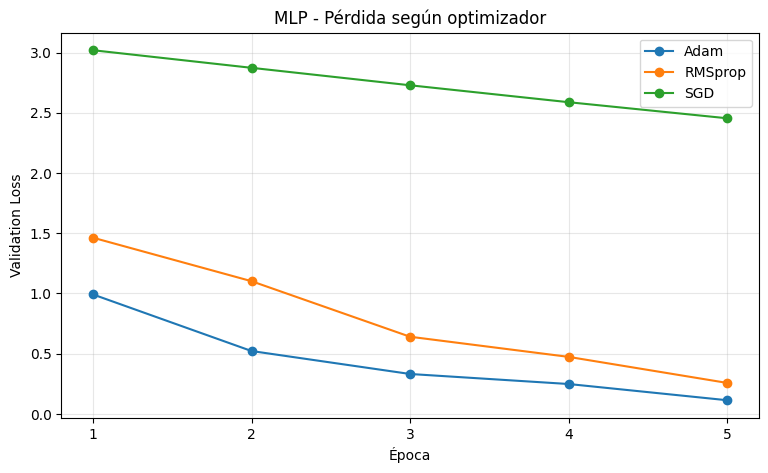

In [368]:
plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    history_mlp_adam.history["val_loss"],
    marker="o",
    label="Adam"
)

plt.plot(
    epocas,
    history_mlp_rmsprop.history["val_loss"],
    marker="o",
    label="RMSprop"
)

plt.plot(
    epocas,
    history_mlp_sgd.history["val_loss"],
    marker="o",
    label="SGD"
)

plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.title("MLP - Pérdida según optimizador")
plt.xticks(epocas)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [369]:
resultados_optimizadores_mlp = pd.DataFrame({
    "Optimizador": [
        "Adam",
        "RMSprop",
        "SGD"
    ],

    "Mejor Val Accuracy": [
        max(history_mlp_adam.history["val_accuracy"]),
        max(history_mlp_rmsprop.history["val_accuracy"]),
        max(history_mlp_sgd.history["val_accuracy"])
    ],

    "Mejor Val Loss": [
        min(history_mlp_adam.history["val_loss"]),
        min(history_mlp_rmsprop.history["val_loss"]),
        min(history_mlp_sgd.history["val_loss"])
    ]
})

resultados_optimizadores_mlp

,Optimizador,Mejor Val Accuracy,Mejor Val Loss
0,Adam,0.976871,0.113802
1,RMSprop,0.931706,0.257569
2,SGD,0.373885,2.454814


### Análisis de optimizadores

Los resultados muestran diferencias importantes en la velocidad de convergencia de los optimizadores evaluados.

Adam presentó el mejor comportamiento, alcanzando aproximadamente un 97,69% de accuracy de validación y la menor pérdida, cercana a 0,11.

RMSprop también logró aprender correctamente el problema, pero presentó una convergencia más lenta y alcanzó aproximadamente un 93,17% de accuracy de validación.

SGD, utilizando el mismo learning rate de 0.001, mostró una convergencia considerablemente más lenta. Después de cinco épocas alcanzó aproximadamente un 37,34% de accuracy de validación y mantuvo una pérdida elevada.

Estos resultados muestran que el algoritmo de optimización influye directamente en la velocidad con que la red ajusta sus pesos y alcanza una solución útil.

### Selección del optimizador

Se selecciona Adam como optimizador para la configuración final de la MLP.

Adam obtuvo la mayor accuracy de validación y la menor pérdida entre los optimizadores evaluados, mostrando además una convergencia rápida y estable.

El resultado de SGD no implica que este optimizador sea inadecuado en términos generales, sino que bajo la configuración evaluada requeriría un ajuste diferente de hiperparámetros o una mayor cantidad de épocas para alcanzar un rendimiento comparable.

### Experimento: número de capas y complejidad de la MLP

En este experimento se analiza el efecto de la profundidad y complejidad de la arquitectura sobre el desempeño de la MLP.

Se comparan tres configuraciones:

- **MLP A:** una capa oculta de 128 neuronas.
- **MLP B:** dos capas ocultas de 256 y 128 neuronas.
- **MLP C:** tres capas ocultas de 256, 128 y 64 neuronas.

Se mantienen constantes:

- Activación oculta = Tanh
- Activación de salida = Softmax
- Función de pérdida = Sparse Categorical Crossentropy
- Optimizador = Adam
- Learning rate = 0.001
- Batch size = 32
- Sin Dropout
- Épocas = 5

De esta forma, la única variable modificada es la arquitectura de la red.

El objetivo es determinar si aumentar o reducir la profundidad de la MLP produce mejoras suficientes para justificar una mayor complejidad.

In [370]:
def crear_mlp_arquitectura(tipo):

    if tipo == "A":
        modelo = models.Sequential([
            layers.Input(shape=(28, 28, 1)),
            layers.Flatten(),

            layers.Dense(128, activation="tanh"),

            layers.Dense(24, activation="softmax")
        ])

    elif tipo == "B":
        modelo = models.Sequential([
            layers.Input(shape=(28, 28, 1)),
            layers.Flatten(),

            layers.Dense(256, activation="tanh"),
            layers.Dense(128, activation="tanh"),

            layers.Dense(24, activation="softmax")
        ])

    elif tipo == "C":
        modelo = models.Sequential([
            layers.Input(shape=(28, 28, 1)),
            layers.Flatten(),

            layers.Dense(256, activation="tanh"),
            layers.Dense(128, activation="tanh"),
            layers.Dense(64, activation="tanh"),

            layers.Dense(24, activation="softmax")
        ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return modelo

In [371]:
tf.keras.utils.set_random_seed(42)

mlp_A = crear_mlp_arquitectura("A")

history_mlp_A = mlp_A.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4504 - loss: 1.9035 - val_accuracy: 0.6354 - val_loss: 1.2547
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7116 - loss: 1.0006 - val_accuracy: 0.7785 - val_loss: 0.8152
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8031 - loss: 0.6909 - val_accuracy: 0.8527 - val_loss: 0.5722
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8610 - loss: 0.5053 - val_accuracy: 0.8924 - val_loss: 0.4156
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9016 - loss: 0.3715 - val_accuracy: 0.9250 - val_loss: 0.3002


In [372]:
tf.keras.utils.set_random_seed(42)

mlp_B = crear_mlp_arquitectura("B")

history_mlp_B = mlp_B.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4647 - loss: 1.7226 - val_accuracy: 0.6897 - val_loss: 0.9920
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7532 - loss: 0.7909 - val_accuracy: 0.8478 - val_loss: 0.5223
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8646 - loss: 0.4569 - val_accuracy: 0.9137 - val_loss: 0.3317
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9195 - loss: 0.2823 - val_accuracy: 0.9361 - val_loss: 0.2484
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9518 - loss: 0.1844 - val_accuracy: 0.9769 - val_loss: 0.1138


In [373]:
tf.keras.utils.set_random_seed(42)

mlp_C = crear_mlp_arquitectura("C")

history_mlp_C = mlp_C.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.4260 - loss: 1.8554 - val_accuracy: 0.6653 - val_loss: 1.0551
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7426 - loss: 0.8228 - val_accuracy: 0.8519 - val_loss: 0.5165
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8643 - loss: 0.4643 - val_accuracy: 0.9017 - val_loss: 0.3458
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9149 - loss: 0.2989 - val_accuracy: 0.9333 - val_loss: 0.2446
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9517 - loss: 0.1804 - val_accuracy: 0.9761 - val_loss: 0.1087


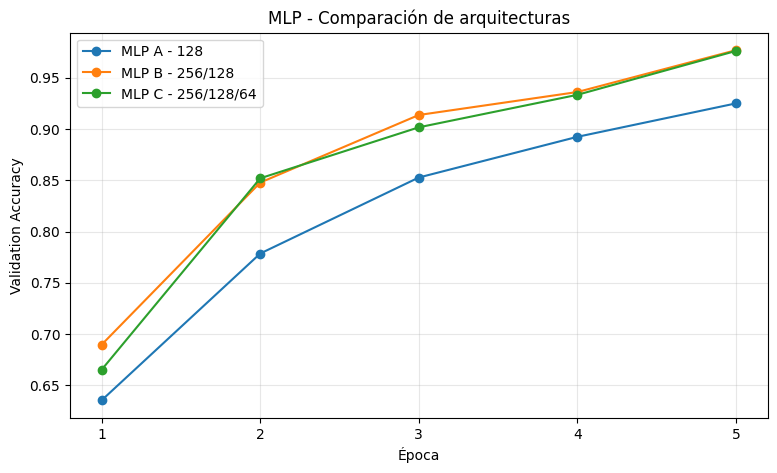

In [374]:
epocas = range(1, 6)

plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    history_mlp_A.history["val_accuracy"],
    marker="o",
    label="MLP A - 128"
)

plt.plot(
    epocas,
    history_mlp_B.history["val_accuracy"],
    marker="o",
    label="MLP B - 256/128"
)

plt.plot(
    epocas,
    history_mlp_C.history["val_accuracy"],
    marker="o",
    label="MLP C - 256/128/64"
)

plt.xlabel("Época")
plt.ylabel("Validation Accuracy")
plt.title("MLP - Comparación de arquitecturas")
plt.xticks(epocas)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

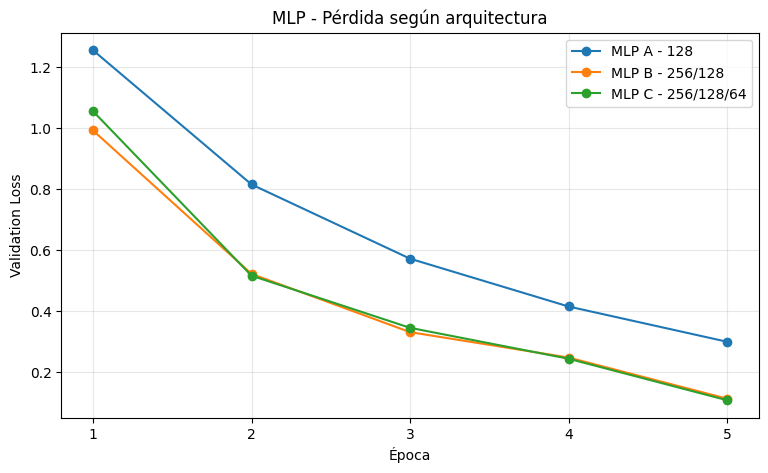

In [375]:
plt.figure(figsize=(9, 5))

plt.plot(
    epocas,
    history_mlp_A.history["val_loss"],
    marker="o",
    label="MLP A - 128"
)

plt.plot(
    epocas,
    history_mlp_B.history["val_loss"],
    marker="o",
    label="MLP B - 256/128"
)

plt.plot(
    epocas,
    history_mlp_C.history["val_loss"],
    marker="o",
    label="MLP C - 256/128/64"
)

plt.xlabel("Época")
plt.ylabel("Validation Loss")
plt.title("MLP - Pérdida según arquitectura")
plt.xticks(epocas)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [376]:
resultados_arquitectura_mlp = pd.DataFrame({
    "Arquitectura": [
        "MLP A - 128",
        "MLP B - 256/128",
        "MLP C - 256/128/64"
    ],

    "Parámetros": [
        mlp_A.count_params(),
        mlp_B.count_params(),
        mlp_C.count_params()
    ],

    "Mejor Val Accuracy": [
        max(history_mlp_A.history["val_accuracy"]),
        max(history_mlp_B.history["val_accuracy"]),
        max(history_mlp_C.history["val_accuracy"])
    ],

    "Mejor Val Loss": [
        min(history_mlp_A.history["val_loss"]),
        min(history_mlp_B.history["val_loss"]),
        min(history_mlp_C.history["val_loss"])
    ]
})

resultados_arquitectura_mlp

,Arquitectura,Parámetros,Mejor Val Accuracy,Mejor Val Loss
0,MLP A - 128,103576,0.924968,0.300174
1,MLP B - 256/128,236952,0.976871,0.113802
2,MLP C - 256/128/64,243672,0.976143,0.108746


### Análisis de la arquitectura

Los resultados muestran que aumentar la capacidad de la MLP mejora considerablemente el rendimiento respecto de una arquitectura con una única capa oculta.

La **MLP A**, con una capa oculta de 128 neuronas, alcanzó aproximadamente un 92,50% de accuracy de validación, mostrando un rendimiento inferior a las arquitecturas más profundas.

La **MLP B**, con capas ocultas de 256 y 128 neuronas, alcanzó aproximadamente un 97,69% de accuracy de validación y una pérdida de 0,1138.

La **MLP C**, que agrega una tercera capa oculta de 64 neuronas, obtuvo un rendimiento prácticamente equivalente, con aproximadamente 97,61% de accuracy. Aunque presentó una pérdida ligeramente menor, requiere una arquitectura más profunda y una mayor cantidad de parámetros.

Los resultados indican que aumentar la profundidad desde una a dos capas ocultas genera una mejora importante, mientras que agregar una tercera capa no produce una mejora observable en accuracy.

## Resumen de experimentos y selección de hiperparámetros

A partir de los experimentos controlados realizados sobre el conjunto de validación, se compararon distintas configuraciones de la MLP modificando un parámetro a la vez.

La siguiente tabla resume los principales resultados y la configuración seleccionada en cada experimento.

In [377]:
resumen_experimentos_mlp = pd.DataFrame({
    "Experimento": [
        "Función de activación",
        "Función de pérdida",
        "Learning rate",
        "Batch size",
        "Dropout",
        "Optimizador",
        "Arquitectura"
    ],

    "Configuraciones evaluadas": [
        "ReLU / Tanh / Sigmoid",
        "Sparse CE / Categorical CE / MSE",
        "0.0001 / 0.001 / 0.01",
        "16 / 32 / 64",
        "Sin Dropout / 0.1 / 0.3",
        "Adam / RMSprop / SGD",
        "128 / 256→128 / 256→128→64"
    ],

    "Mejor Val Accuracy": [
        0.976871,
        0.976871,
        0.976871,
        0.976871,
        0.976871,
        0.976871,
        0.976871
    ],

    "Selección": [
        "Tanh",
        "Sparse Categorical Crossentropy",
        "0.001",
        "32",
        "Sin Dropout",
        "Adam",
        "256 → 128"
    ]
})

resumen_experimentos_mlp

,Experimento,Configuraciones evaluadas,Mejor Val Accuracy,Selección
0,Función de activación,ReLU / Tanh / Sigmoid,0.976871,Tanh
1,Función de pérdida,Sparse CE / Categorical CE / MSE,0.976871,Sparse Categorical Crossentropy
2,Learning rate,0.0001 / 0.001 / 0.01,0.976871,0.001
3,Batch size,16 / 32 / 64,0.976871,32
4,Dropout,Sin Dropout / 0.1 / 0.3,0.976871,Sin Dropout
5,Optimizador,Adam / RMSprop / SGD,0.976871,Adam
6,Arquitectura,128 / 256→128 / 256→128→64,0.976871,256 → 128


### Configuración final seleccionada

A partir de los experimentos realizados, la configuración final de la MLP queda definida de la siguiente manera:

- **Entrada:** imágenes de 28 × 28 píxeles en escala de grises.
- **Flatten:** transformación de la imagen a un vector de 784 características.
- **Primera capa oculta:** 256 neuronas con activación Tanh.
- **Segunda capa oculta:** 128 neuronas con activación Tanh.
- **Capa de salida:** 24 neuronas con activación Softmax.
- **Función de pérdida:** Sparse Categorical Crossentropy.
- **Optimizador:** Adam.
- **Learning rate:** 0.001.
- **Batch size:** 32.
- **Dropout:** no utilizado.
- **Épocas:** 5.

La selección se realizó utilizando exclusivamente el rendimiento sobre el conjunto de validación. El conjunto de prueba se mantiene independiente y se utiliza posteriormente para medir la capacidad de generalización del modelo seleccionado.

### Selección de la arquitectura

Se selecciona la **MLP B (256 → 128)** como arquitectura final.

Esta configuración presenta el mejor equilibrio entre rendimiento y complejidad:

- supera claramente a la arquitectura con una sola capa oculta,
- alcanza la mayor accuracy de validación entre las configuraciones evaluadas,
- utiliza menos parámetros que la arquitectura de tres capas ocultas,
- agregar una tercera capa no produjo una mejora observable.

Por lo tanto, la arquitectura final queda compuesta por dos capas ocultas de 256 y 128 neuronas.

## Evaluación final de la MLP sobre el conjunto de prueba

Después de seleccionar la configuración final utilizando exclusivamente los datos de entrenamiento y validación, el modelo se evalúa sobre el conjunto de prueba independiente.

La MLP obtuvo:

- **Test Accuracy:** 77,89%
- **Test Loss:** 0,7534

Este resultado es inferior al accuracy de validación, que alcanzó aproximadamente 97,69%.

La diferencia indica que el desempeño observado durante la validación fue más optimista que el obtenido sobre datos completamente independientes.

Por esta razón, resulta necesario analizar métricas por clase, la matriz de confusión y ejemplos de predicciones para identificar dónde se concentran los principales errores del modelo.

In [378]:
modelo_mlp_final = mlp_B

test_loss_mlp, test_acc_mlp = modelo_mlp_final.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test Accuracy MLP final: {test_acc_mlp:.4f}")
print(f"Test Loss MLP final: {test_loss_mlp:.4f}")

Test Accuracy MLP final: 0.7789
Test Loss MLP final: 0.7534


In [379]:
predicciones_mlp = modelo_mlp_final.predict(
    X_test,
    verbose=0
)

y_pred_mlp = np.argmax(
    predicciones_mlp,
    axis=1
)

print("Predicciones:", y_pred_mlp.shape)
print("Etiquetas reales:", y_test.shape)

Predicciones: (7172,)
Etiquetas reales: (7172,)


In [380]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_mlp,
        labels=range(24),
        target_names=nombres_clases,
        digits=4
    )
)

              precision    recall  f1-score   support

           A     0.8417    0.9637    0.8986       331
           B     0.9754    0.9167    0.9451       432
           C     0.8627    0.9323    0.8961       310
           D     0.9859    0.8571    0.9170       245
           E     0.8779    0.9960    0.9332       498
           F     0.7568    0.8947    0.8200       247
           G     0.8601    0.7069    0.7760       348
           H     0.8857    0.9060    0.8957       436
           I     0.8591    0.6562    0.7441       288
           K     0.9627    0.3897    0.5548       331
           L     0.8261    1.0000    0.9048       209
           M     0.7370    0.7183    0.7275       394
           N     0.7654    0.6392    0.6966       291
           O     1.0000    0.8252    0.9042       246
           P     0.9912    0.9741    0.9826       347
           Q     0.7622    0.8598    0.8080       164
           R     0.4522    0.4931    0.4718       144
           S     0.6000    

In [381]:
from sklearn.metrics import precision_recall_fscore_support

precision_mlp, recall_mlp, f1_mlp, support_mlp = (
    precision_recall_fscore_support(
        y_test,
        y_pred_mlp,
        labels=range(24),
        zero_division=0
    )
)

metricas_mlp = pd.DataFrame({
    "Clase": nombres_clases,
    "Precision": precision_mlp,
    "Recall": recall_mlp,
    "F1-score": f1_mlp,
    "Support": support_mlp
})

metricas_mlp

,Clase,Precision,Recall,F1-score,Support
0,A,0.841689,0.963746,0.898592,331
1,B,0.975369,0.916667,0.945107,432
2,C,0.862687,0.932258,0.896124,310
3,D,0.985915,0.857143,0.917031,245
4,E,0.877876,0.995984,0.933208,498
5,F,0.756849,0.894737,0.820037,247
6,G,0.860140,0.706897,0.776025,348
7,H,0.885650,0.905963,0.895692,436
8,I,0.859091,0.656250,0.744094,288
9,K,0.962687,0.389728,0.554839,331


In [382]:
from sklearn.metrics import accuracy_score

resumen_metricas_mlp = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision Macro",
        "Recall Macro",
        "F1 Macro"
    ],
    "Valor": [
        accuracy_score(y_test, y_pred_mlp),
        precision_mlp.mean(),
        recall_mlp.mean(),
        f1_mlp.mean()
    ]
})

resumen_metricas_mlp

,Métrica,Valor
0,Accuracy,0.778862
1,Precision Macro,0.775497
2,Recall Macro,0.765012
3,F1 Macro,0.760567


### Análisis de las métricas de la MLP final

La MLP final obtuvo una accuracy aproximada de **77,89%** sobre el conjunto de prueba.

Las métricas macro fueron:

- Precision Macro: 77,55%
- Recall Macro: 76,50%
- F1-score Macro: 76,06%

Se utilizan métricas **Macro** porque calculan la métrica de forma independiente para cada una de las 24 clases y posteriormente obtienen el promedio, otorgando el mismo peso a cada clase sin importar cuántos ejemplos contenga.

Esto permite evaluar de forma más equilibrada el comportamiento del modelo entre las distintas letras y evita que las clases con mayor cantidad de ejemplos dominen el resultado global.

Estos valores muestran que el rendimiento no es uniforme entre todas las clases.

Algunas letras presentan un desempeño elevado. Por ejemplo, B, E y P alcanzan valores altos de Precision, Recall y F1-score.

Sin embargo, otras clases presentan mayores dificultades.

La clase **K** presenta una Precision cercana a 0,96, pero un Recall de aproximadamente 0,39. Esto significa que cuando el modelo predice K generalmente acierta, pero una gran cantidad de ejemplos reales de K son clasificados como otras letras.

La clase **R** también presenta un desempeño bajo, con un F1-score cercano a 0,47.

Por otro lado, clases como **V** y **W** presentan valores de Precision bajos, lo que indica que ejemplos de otras clases están siendo predichos incorrectamente como esas letras.

Estos resultados muestran que la accuracy global no es suficiente para evaluar completamente un problema multiclase y que es necesario analizar Precision, Recall y F1-score de forma individual.

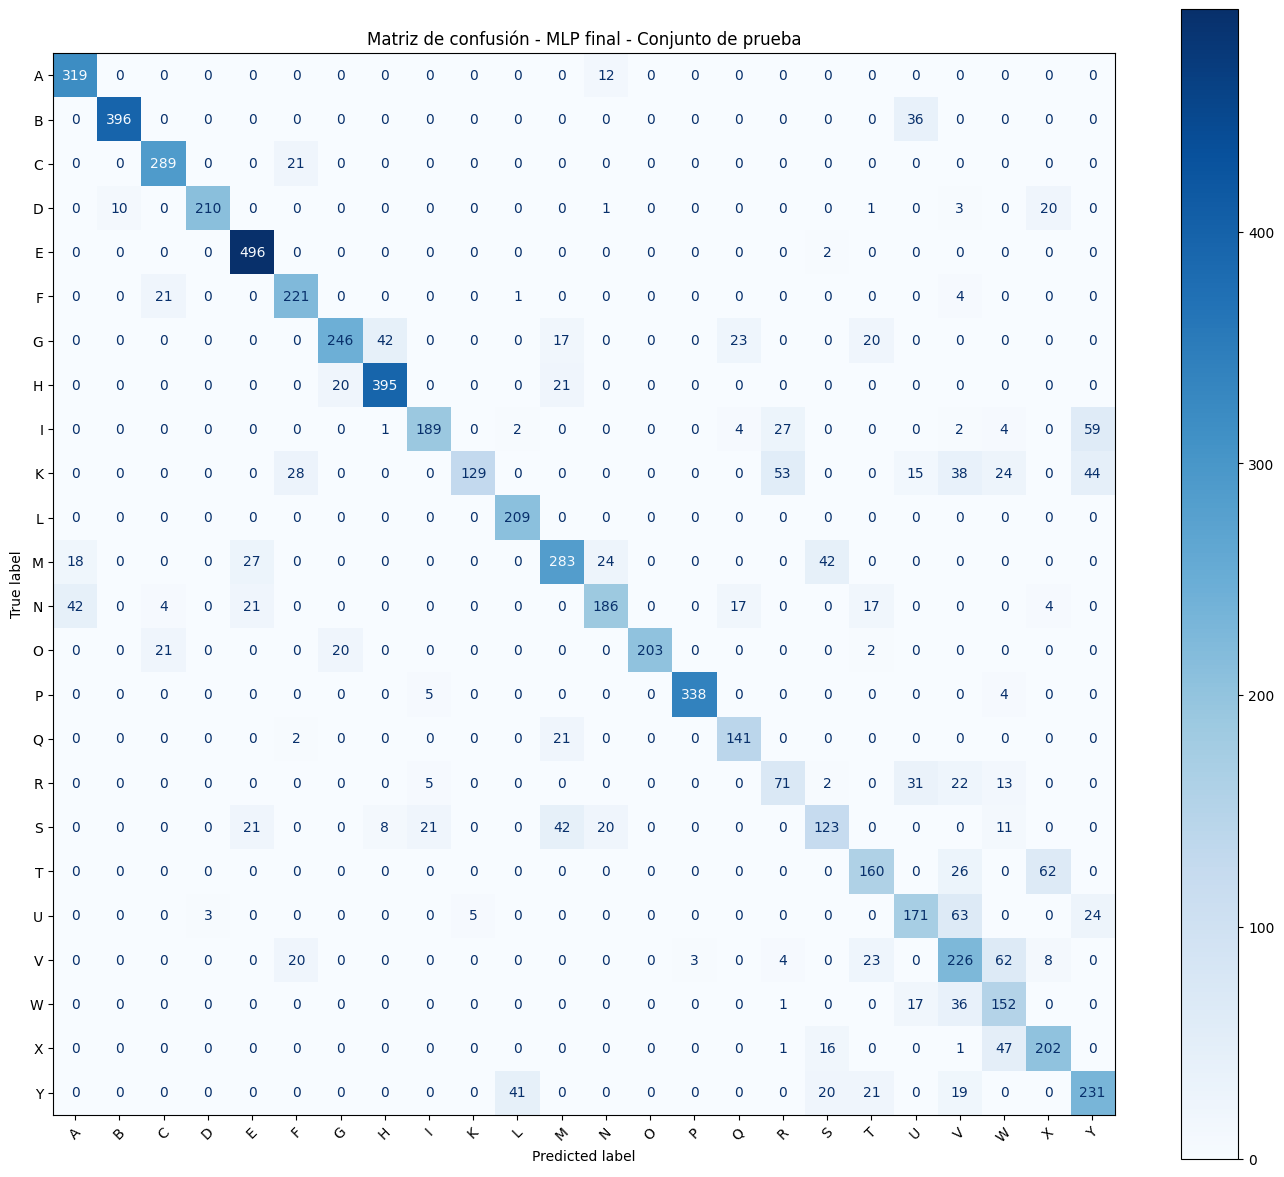

In [383]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_mlp = confusion_matrix(
    y_test,
    y_pred_mlp,
    labels=range(24)
)

fig, ax = plt.subplots(figsize=(14, 12))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_mlp,
    display_labels=nombres_clases
)

disp.plot(
    cmap="Blues",
    ax=ax,
    values_format="d",
    colorbar=True
)

plt.title("Matriz de confusión - MLP final - Conjunto de prueba")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

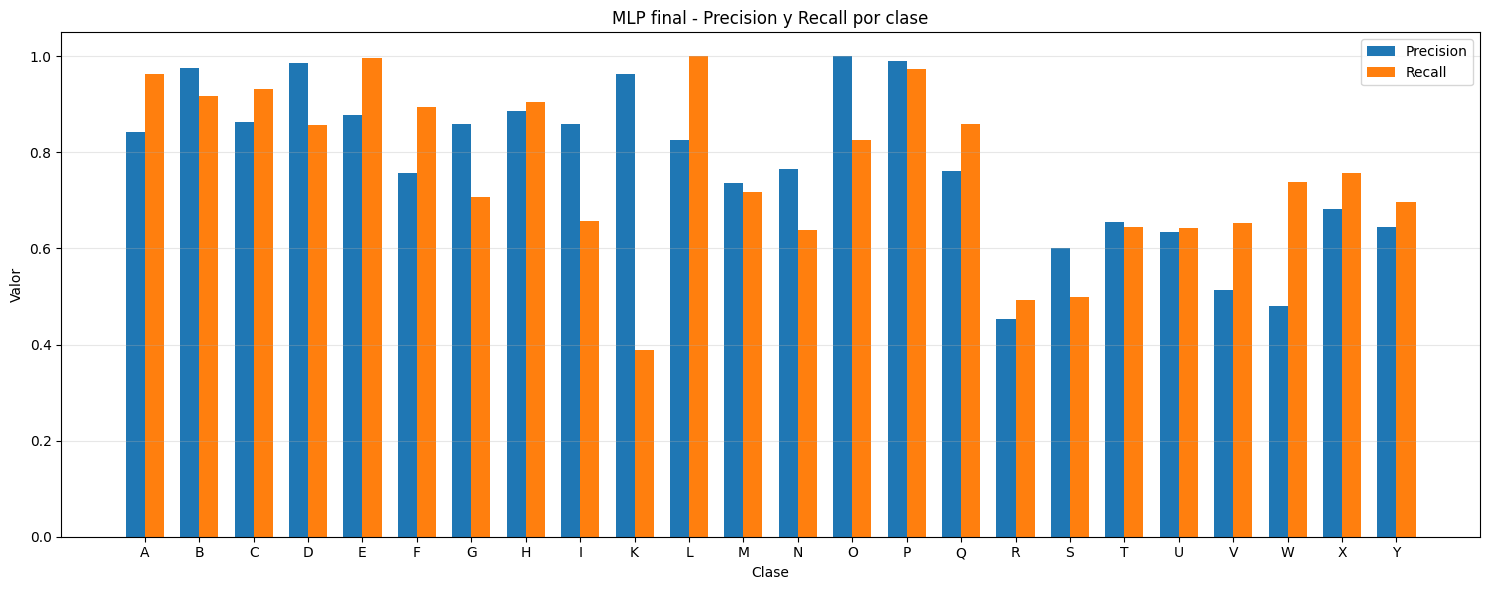

In [384]:
x = np.arange(len(nombres_clases))
width = 0.35

plt.figure(figsize=(15, 6))

plt.bar(
    x - width/2,
    precision_mlp,
    width,
    label="Precision"
)

plt.bar(
    x + width/2,
    recall_mlp,
    width,
    label="Recall"
)

plt.xticks(x, nombres_clases)
plt.ylim(0, 1.05)

plt.xlabel("Clase")
plt.ylabel("Valor")
plt.title("MLP final - Precision y Recall por clase")

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

### Análisis de la matriz de confusión

La matriz de confusión muestra que el rendimiento de la MLP varía considerablemente entre las distintas letras.

Clases como B, E, L, O y P presentan una alta concentración de ejemplos en la diagonal principal, lo que indica una buena capacidad de clasificación.

Sin embargo, otras clases presentan mayores dificultades.

La clase K muestra una cantidad importante de falsos negativos, ya que sólo una parte de sus ejemplos reales son correctamente reconocidos. Esto es coherente con su bajo Recall.

La clase R también presenta numerosas confusiones con otras clases.

Además, se observan errores entre letras como V y W, lo que sugiere que determinadas configuraciones de la mano pueden presentar características visuales similares para la red.

Estos resultados muestran que el rendimiento global de la MLP está condicionado por un conjunto específico de clases difíciles de diferenciar.

### Interpretación de Precision y Recall

El gráfico permite identificar distintos tipos de error según la clase.

Por ejemplo, la letra K presenta una Precision elevada pero un Recall bajo. Esto significa que las predicciones realizadas como K suelen ser correctas, pero una gran proporción de las K reales no son detectadas.

La clase R presenta valores bajos tanto de Precision como de Recall, indicando dificultades tanto para reconocer ejemplos reales de R como para evitar falsos positivos.

En clases como W, el Recall es superior a la Precision, lo que indica que el modelo identifica una proporción importante de las W reales, pero también clasifica incorrectamente otras letras como W.

Este análisis permite identificar qué clases requieren mejoras específicas y demuestra por qué Precision y Recall entregan información que no puede observarse únicamente mediante Accuracy.

In [385]:
indice_k = nombres_clases.index("K")

TP_k = cm_mlp[indice_k, indice_k]
FP_k = cm_mlp[:, indice_k].sum() - TP_k
FN_k = cm_mlp[indice_k, :].sum() - TP_k
TN_k = cm_mlp.sum() - (TP_k + FP_k + FN_k)

accuracy_k = (TP_k + TN_k) / (TP_k + TN_k + FP_k + FN_k)
precision_k = TP_k / (TP_k + FP_k)
recall_k = TP_k / (TP_k + FN_k)
f1_k = 2 * (precision_k * recall_k) / (precision_k + recall_k)

print("Clase K")
print("TP:", TP_k)
print("FP:", FP_k)
print("FN:", FN_k)
print("TN:", TN_k)
print()

print(f"Accuracy binaria: {accuracy_k:.4f}")
print(f"Precision: {precision_k:.4f}")
print(f"Recall: {recall_k:.4f}")
print(f"F1-score: {f1_k:.4f}")

Clase K
TP: 129
FP: 5
FN: 202
TN: 6836

Accuracy binaria: 0.9711
Precision: 0.9627
Recall: 0.3897
F1-score: 0.5548


### Ejemplo numérico de métricas: clase K

Para comprender el cálculo de las métricas, la clase K se analiza como un problema binario: K frente a no-K.

A partir de la matriz de confusión se obtienen:

- TP = 129
- FP = 5
- FN = 202
- TN = 6836

La Accuracy se calcula como:

`Accuracy = (TP + TN) / (TP + TN + FP + FN)`

`Accuracy = (129 + 6836) / 7172 ≈ 0,9711`

Esto indica una Accuracy binaria aproximada de 97,11%. Sin embargo, este valor debe interpretarse con cautela, ya que existe una gran cantidad de verdaderos negativos correspondientes a todas las clases que no son K.

La Precision se calcula como:

`Precision = TP / (TP + FP)`

`Precision = 129 / (129 + 5) ≈ 0,9627`

Esto significa que aproximadamente el 96,27% de las imágenes predichas como K realmente correspondían a K.

El Recall se calcula como:

`Recall = TP / (TP + FN)`

`Recall = 129 / (129 + 202) ≈ 0,3897`

Esto significa que el modelo sólo logró identificar aproximadamente el 38,97% de todas las K reales.

El F1-score combina Precision y Recall:

`F1 = 2 × (Precision × Recall) / (Precision + Recall)`

`F1 ≈ 0,5548`

Este ejemplo demuestra que una Accuracy elevada no garantiza un buen desempeño para una clase específica. Aunque la Accuracy binaria de K es cercana al 97%, el bajo Recall revela que el modelo no logra reconocer una gran proporción de las K reales.

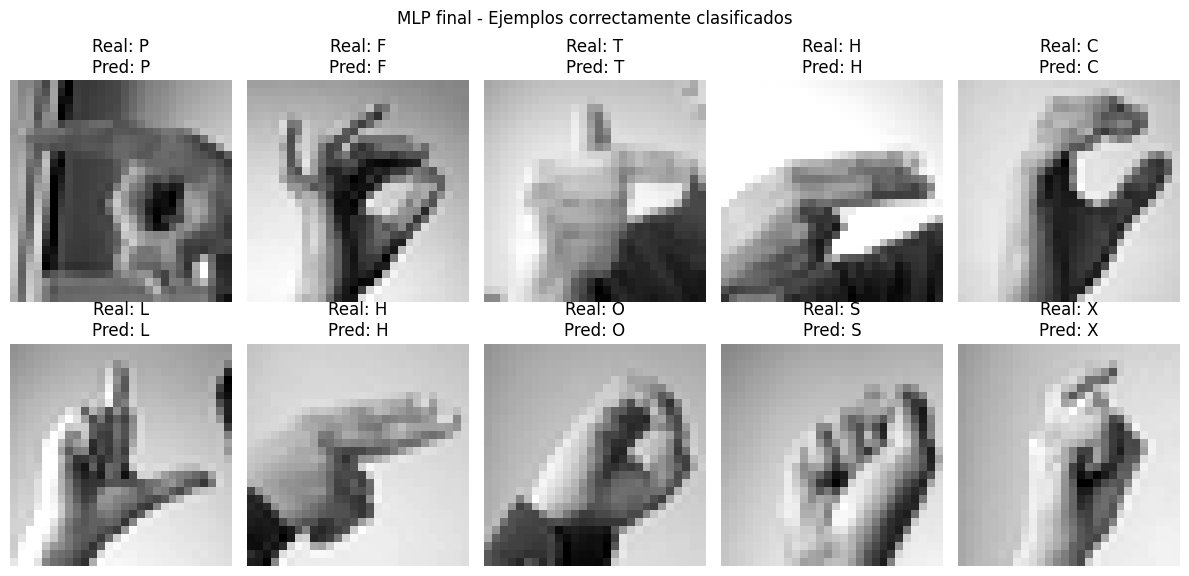

In [386]:
indices_correctos_mlp = np.where(y_pred_mlp == y_test)[0]

np.random.seed(42)
muestra_correctos = np.random.choice(
    indices_correctos_mlp,
    size=10,
    replace=False
)

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for ax, idx in zip(axes.flatten(), muestra_correctos):

    real = nombres_clases[y_test[idx]]
    pred = nombres_clases[y_pred_mlp[idx]]

    ax.imshow(
        X_test[idx].reshape(28, 28),
        cmap="gray"
    )

    ax.set_title(
        f"Real: {real}\nPred: {pred}"
    )

    ax.axis("off")

plt.suptitle("MLP final - Ejemplos correctamente clasificados")
plt.tight_layout()
plt.show()

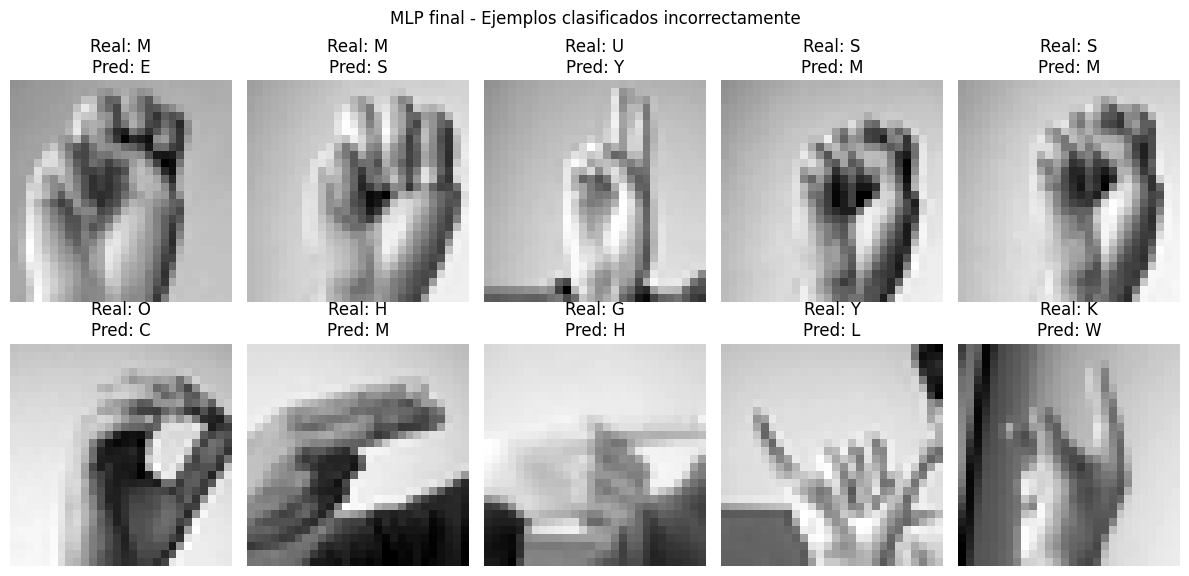

In [387]:
indices_errores_mlp = np.where(y_pred_mlp != y_test)[0]

np.random.seed(42)
muestra_errores = np.random.choice(
    indices_errores_mlp,
    size=10,
    replace=False
)

fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for ax, idx in zip(axes.flatten(), muestra_errores):

    real = nombres_clases[y_test[idx]]
    pred = nombres_clases[y_pred_mlp[idx]]

    ax.imshow(
        X_test[idx].reshape(28, 28),
        cmap="gray"
    )

    ax.set_title(
        f"Real: {real}\nPred: {pred}"
    )

    ax.axis("off")

plt.suptitle("MLP final - Ejemplos clasificados incorrectamente")
plt.tight_layout()
plt.show()

### Análisis visual de aciertos y errores

La visualización de ejemplos permite complementar las métricas numéricas con una interpretación directa de las predicciones realizadas por la MLP.

En los ejemplos correctamente clasificados se observa que el modelo es capaz de reconocer distintos tipos de configuraciones de la mano, incluso cuando existen variaciones en posición, orientación y apariencia.

En los ejemplos incorrectos aparecen confusiones como M→E, M→S, U→Y, S→M, O→C, H→M, G→H, Y→L y K→W.

Estos errores sugieren que algunas letras presentan características visuales similares cuando son representadas mediante una única imagen de baja resolución.

El análisis visual es coherente con la matriz de confusión y con las métricas por clase, donde determinadas letras presentan valores de Recall o Precision considerablemente inferiores al promedio.

Por lo tanto, una posible mejora futura sería utilizar imágenes de mayor resolución, aumentar la variabilidad de los ejemplos de entrenamiento o incorporar técnicas capaces de capturar mejor las relaciones espaciales presentes en la imagen.

## Persistencia de la MLP final

Una vez seleccionada y evaluada la configuración final, el modelo se guarda en formato `.keras`.

Esto permite almacenar la arquitectura, los pesos aprendidos y la configuración del modelo para reutilizarlo posteriormente sin necesidad de volver a entrenarlo.

El modelo guardado se carga nuevamente y se evalúa sobre el conjunto de prueba para comprobar que mantiene el mismo rendimiento.

In [388]:
modelo_mlp_final.save("sign_language_mlp_final.keras")

print("Modelo MLP guardado correctamente.")

Modelo MLP guardado correctamente.


In [389]:
modelo_mlp_cargado = tf.keras.models.load_model(
    "sign_language_mlp_final.keras"
)

loss_cargado, acc_cargado = modelo_mlp_cargado.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Accuracy modelo cargado: {acc_cargado:.4f}")
print(f"Loss modelo cargado: {loss_cargado:.4f}")

Accuracy modelo cargado: 0.7789
Loss modelo cargado: 0.7534


## Conclusiones

En este trabajo se implementó y evaluó una red neuronal artificial tipo **MLP** para la clasificación de imágenes del conjunto Sign Language MNIST.

El proceso incluyó la preparación de los datos, normalización de los píxeles, remapeo de las etiquetas y separación de los conjuntos de entrenamiento, validación y prueba.

Posteriormente se realizaron experimentos controlados modificando un parámetro a la vez. Se compararon funciones de activación, funciones de pérdida, learning rate, batch size, Dropout, optimizadores y distintas arquitecturas de la MLP.

La configuración seleccionada fue:

- Arquitectura: 784 → 256 → 128 → 24.
- Activación en capas ocultas: Tanh.
- Activación de salida: Softmax.
- Función de pérdida: Sparse Categorical Crossentropy.
- Optimizador: Adam.
- Learning rate: 0.001.
- Batch size: 32.
- Dropout: no utilizado.
- Épocas: 5.

La configuración final alcanzó aproximadamente un **97,69% de accuracy en validación**.

Al evaluar posteriormente el modelo sobre el conjunto de prueba independiente, se obtuvo una **accuracy de 77,89%**, mostrando una diferencia importante respecto del rendimiento observado en validación.

Las métricas globales obtenidas en test fueron aproximadamente:

- Accuracy: 77,89%.
- Precision Macro: 77,55%.
- Recall Macro: 76,50%.
- F1-score Macro: 76,06%.

El análisis por clase mostró que el rendimiento no es uniforme. Algunas letras presentan resultados elevados, mientras que otras, como K y R, presentan mayores dificultades de clasificación.

En particular, la clase K mostró una Precision aproximada de 96,27%, pero un Recall de sólo 38,97%, demostrando que una única métrica no es suficiente para evaluar correctamente el comportamiento del modelo.

La matriz de confusión y el análisis visual de los errores evidenciaron confusiones entre determinados gestos visualmente similares.

Como trabajo futuro, se podría estudiar el uso de más datos, técnicas adicionales de regularización, aumento de datos y arquitecturas especializadas para imágenes, con el objetivo de mejorar la capacidad de generalización sobre datos no utilizados durante el entrenamiento.

Finalmente, el modelo fue almacenado en formato `.keras` y cargado nuevamente, verificando que conserva su rendimiento y puede ser reutilizado sin necesidad de volver a entrenarlo.

## Repositorio del proyecto

El código fuente y las instrucciones de ejecución se encuentran disponibles en GitHub:

**Repositorio:** https://github.com/rikenichi/EP1_DeepLearning_SignLanguage_MLP.ipynb.git

El repositorio contiene el notebook principal y un archivo README con las instrucciones necesarias para reproducir la ejecución en Google Colab.

## Referencias

Para la implementación y análisis del modelo se consultó documentación oficial de las bibliotecas utilizadas:

- [Keras — Sequential model](https://keras.io/api/models/sequential/)
- [Keras — Dense layer](https://keras.io/api/layers/core_layers/dense/)
- [Keras — Activation functions](https://keras.io/api/layers/activations/)
- [Keras — Probabilistic losses](https://keras.io/api/losses/probabilistic_losses/)
- [Keras — Adam optimizer](https://keras.io/api/optimizers/adam/)
- [Keras — Dropout layer](https://keras.io/api/layers/regularization_layers/dropout/)
- [Scikit-learn — Classification report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)
- [Scikit-learn — Confusion matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)